# Four-corner mean Z4 (OPD) against truss, ambient and camera-body temperature

**Author:** Aaron Roodman (with Claude Code)
**Date created:** 2026-09-09
**Last modified:** 2026-09-09
**Status:** current
**Keywords:** AOS, corner wavefront sensor, Z4, defocus, v-mode 1, truss temperature, ConsDB, EFD

## Description

Tests whether the total Active Optics System (AOS) optical state on ordinary **science**
exposures correlates with Telescope Mount Assembly (TMA) truss temperature, outside ambient
temperature, or camera-body temperature.

The total is assembled as

```
v1_total = v1(hexapod LUT) + v1(Trim) + v1_equivalent(four-corner mean Z4)
```

where LUT is the hexapod look-up table (the elevation- and temperature-dependent baseline)
and Trim is the accumulated closed-loop offset. A physical hexapod position is LUT + Trim; the
third term converts the *measured* wavefront into the equivalent commanded motion, so all
three are in the same dimensionless v-mode-1 units and can be added.

The measured term is the **four-corner mean Z4 (OPD)** — the mean over the four corner
wavefront sensors of the total optical path difference (OPD) Zernike 4 that the Consolidated
Database (ConsDB) stores per CCD. It is deliberately *not* called DZ(1,4): four field points
cannot separate a field-constant defocus from real field tilt, and this is a different
estimator from the 189-detector Double Zernike (DZ) fit used in
`code/correlations/run_dz14_truss.py`. The batoid intrinsic wavefront is not subtracted — it
is small and nearly field-constant, so it displaces the zero point without changing any slope
(Section 5 prints the four per-corner intrinsic Z4 values so the size of that assumption is
visible rather than assumed).

Complements `run_dz14_truss.py`, which asks the same physical question on Full Array Mode
(FAM) exposures with a 189-detector DZ fit. Science exposures carry corner Zernikes for free,
so this is a much larger and differently-selected sample.

## Output

`aos/output/notebooks/correlations/corner_z4_vs_temperature_science*.{parquet,png}`

## References

- `aos/docs/studies/correlations.md` — the study this belongs to
- `aos/docs/telemetry.md` — LUT / Trim / Tweak column mapping and ConsDB coverage
- `olr/docs/zernike_opd_vs_consdb.md` — ConsDB corner Zernikes are total OPD, not deviation
- `olr/docs/vmode_normalization.md` — why the v-modes must come from the OFC config weights

## Change log

| date | change |
|---|---|
| 2026-09-09 | initial version |

## Table of contents

1. [Parameters](#params)
2. [Imports and clients](#imports)
3. [Science visits](#visits)
4. [v-mode machinery and the two routes](#vmodes)
5. [Intrinsic Z4 — how constant is "constant"?](#intrinsic)
6. [Fetch: corner Z4, LUT, Trim, temperatures](#fetch)
7. [Assemble `v1_total`](#assemble)
8. [Sign check against the BLOCK-T539 initial-alignment sequence](#signcheck)
9. [Scatter against temperature, by band](#scatter)
10. [Residuals about the truss relation, by band](#resid)
11. [Does any other thermal channel add information beyond the truss?](#thermalml)
12. [Time history of the thermal residual within a night](#timehist)
13. [Per-visit summary table](#summary)
14. [Findings](#findings)


<a id="params"></a>
## 1. Parameters

In [2]:
import numpy as np          # np.logspace is used in the ML grid below

# --- selection ---------------------------------------------------------------
DAY_OBS_MIN = 20260419
DAY_OBS_MAX = 20260713
IMG_TYPE = 'science'
BANDS = ['g', 'r', 'i', 'z']
INSTRUMENT = 'lsstcam'

# --- v-mode construction -----------------------------------------------------
DOF_SET = 'standard_22'      # 10 rigid + M1M3 bending 1-7 + M2 bending 1-5
N_MODES = 12
K_MIN, K_MAX = 1, 6          # focal-Zernike order range, matching the DZ fits

# v-mode 1 per um of hexapod dz, the mean of the camera- and M2-hexapod dz coefficients
# (they agree to 2.1%). Recomputed from the SVD in Section 4 and checked against this.
V1_PER_UM_DZ_EXPECT = 9.0095e-4          # [1/um]
DZ_TO_UM_EXPECT = -1110.03               # [um of hexapod dz per um of wavefront]

# Overall sign of the measured-wavefront term when it is added to the commanded state.
#
#   v1_total = v1(LUT) + v1(Trim) + MEASURED_SIGN * v1_equivalent(four-corner mean Z4)
#
# This is a genuine free convention, not a fitted quantity. Two sign conventions compose into
# it and neither is pinned down by anything measured here: the sign of the ConsDB corner OPD
# Z4 relative to the batoid/OFC wavefront convention, and the sign of DZ_TO_UM (which is
# itself negative, -1110.03 um of hexapod dz per um of wavefront). With MEASURED_SIGN = -1
# the composed map from OPD Z4 to v-mode 1 is net POSITIVE; with +1 it is net negative.
#
# Physically the measured term should OPPOSE the commanded one: if the commanded state already
# put the telescope in focus, whatever defocus the wavefront still shows is the part the
# command did not achieve, so adding it should reduce the scatter of the total rather than
# increase it. Section 7 tests exactly that, reporting both signs side by side -- but see the
# caveat there: the measured term is small enough that the truss relation cannot resolve it.
#
# Set this to +1.0 or -1.0 and re-run from Section 7 to compare the two outputs.
MEASURED_SIGN = -1.0
MEASURED_SIGNS = (+1.0, -1.0)   # both are always reported as a diagnostic

# --- sign check: the BLOCK-T539 initial-alignment sequence (Section 8) ------------------
# Each night opens with an in-focus acquisition sequence that walks the telescope into focus
# from a large focus error, which makes the sign of the measured wavefront relative to the
# commanded correction directly visible. On 20260513 that is seq_num 10-19, science_program
# BLOCK-T539, observation_reason 'infocus_initial_alignment'.
#
# The block applies the correction derived from image n only at image n+2 -- n+1's correction
# is never used -- so the AOS emits a degreeOfFreedom event only on the even seq_nums.
SIGN_DAY_OBS = 20260513
SIGN_SEQ_MIN, SIGN_SEQ_MAX = 10, 19
SIGN_BLOCK = 'BLOCK-T539'
# EFD topics for the chain. wavefrontError is the OFC's INPUT (4 rows per visit, one per
# corner sensor); degreeOfFreedom carries opticalState, visitDoF (Tweak), aggregatedDoF (Trim)
# and the PID gains, all co-emitted on one event.
WFE_TOPIC = 'lsst.sal.MTAOS.logevent_wavefrontError'
DOF_TOPIC = 'lsst.sal.MTAOS.logevent_degreeOfFreedom'
# v-mode-1 amplitude per um of hexapod dz, per hexapod, from the DOF route (Section 4).
V1_PER_UM_DZ_CAM = -8.9153336e-04    # DOF5, camera hexapod dz [1/um]
V1_PER_UM_DZ_M2 = -9.1035126e-04     # DOF0, M2 hexapod dz     [1/um]

# --- temperatures ------------------------------------------------------------------------
# Most channels come from the ConsDB transformed EFD (efd_lsstcam.exposure_efd), named as in
# aos_consdb_efd.TEMP_COLS. The CAMERA BODY temperature does NOT: it is camera housekeeping,
# published to the camera's OWN InfluxDB database (lsst.MTCamera), so it needs a second EFD
# client -- see aos/code/fam_processing/run_attach_telemetry.py, which attaches the same
# quantity to the FAM visits.parquet.
TRUSS_COLS = ['tma_truss_temp_pxpy', 'tma_truss_temp_mxmy']   # salindex122 temperature_6,_7
AMBIENT_COL = 'outside_temp'                                  # salindex301 temperature_0_mean

# Camera-body temperature, from lsst.MTCamera (NOT the ESS). Only AverageTemp is pulled here;
# run_attach_telemetry.py fetches all 24 channels for the FAM tables.
CAM_TOPIC = 'lsst.MTCamera.utiltrunk_body'
CAM_DB = 'lsst.MTCamera'
CAM_FIELD = 'AverageTemp'
CAM_COL = 'cam_AverageTemp'                                   # deg C, camera body
CAM_T_RANGE = (-50.0, 60.0)      # a reading outside this is a dropout, not a temperature
CAM_PAD_SEC = 120.0              # utility-trunk housekeeping is the slowest-sampled channel

# cam_air_temp is the AIR temperature near the camera (salindex-111 ESS), a DIFFERENT quantity
# from the camera body temperature above -- both are kept as independent thermal channels.
CAMERA_AIR_COL = 'cam_air_temp'                               # salindex111 temperature_0_mean

# The thermal parameter array for Section 10, matching CORE_THERMAL as used for the FAM
# visits.parquet, plus the camera-body AverageTemp. The three *_delta_t columns are derived by
# aos_consdb_efd from the air temperatures (m2 - m1m3, cam - m1m3, outside - m1m3).
CORE_THERMAL = [
    'cam_air_temp', 'm2_air_temp', 'm1m3_air_temp', 'outside_temp',
    'm2_delta_t', 'cam_m1m3_delta_t', 'dome_delta_t',
    'tma_truss_temp_pxpy', 'tma_truss_temp_mxmy', CAM_COL,
]

# --- machine learning: does any thermal channel add information beyond the truss? --------
# Grouped by day_obs so a night never straddles the train/test split: thermal state is
# strongly correlated within a night, and an ungrouped split would leak it and inflate every
# score. The baseline to beat is the truss-only linear fit.
ML_N_SPLITS = 5              # GroupKFold folds, grouped on day_obs
ML_RANDOM_STATE = 12345
ML_ALPHAS = np.logspace(-3, 3, 25)      # ridge regularization grid [dimensionless]
ML_GB_PARAMS = dict(n_estimators=300, max_depth=3, learning_rate=0.05,
                    subsample=0.8, random_state=ML_RANDOM_STATE)
ML_N_PERM = 20               # permutation-importance repeats

# --- time history of the thermal residual (Section 11) ----------------------------------
# Two zero points per night, both reported in UTC as validation:
#   a) zero-degree evening twilight -- sun geometry, independent of what was observed
#   b) the first science-or-acq exposure -- when imaging actually started
TWILIGHT_SUN_ALT_DEG = 0.0   # "zero-degree twilight": sun geometric altitude = 0 deg
RUBIN_LAT_DEG = -30.244639   # Simonyi Survey Telescope, Cerro Pachon
RUBIN_LON_DEG = -70.749417
RUBIN_HEIGHT_M = 2663.0
FIRST_IMG_TYPES = ('science', 'acq')    # for zero point (b)
MIN_PTS_PER_NIGHT = 10       # nights with fewer visits get no per-night line or slope
TIME_BIN_H = 1.0             # width of the time bins for the across-night median [h]
MIN_NIGHTS_PER_BIN = 5       # bins backed by fewer nights are not drawn

# --- image quality and pressure from the ConsDB (Section 13) -----------------------------
# All three image-quality columns live in cdb_<instrument>.visit1_quicklook and arrive as
# OBJECT dtype from the ConsDB, so every one is pushed through pd.to_numeric before use.
# psf_sigma_median is a Gaussian sigma in PIXELS; the repo converts it to a FWHM in arcsec
# with the Gaussian factor and the 0.2 arcsec/pixel plate scale, as in
# blocks/code/build_t539_table.py and aos/notebooks/processing_compare/.
IQ_COLS = ['donut_blur_fwhm', 'aos_fwhm', 'psf_sigma_median']
SIGMA_TO_FWHM = 2.0 * np.sqrt(2.0 * np.log(2.0))   # 2.3548, dimensionless
PIXEL_SCALE_ARCSEC = 0.2                            # arcsec per pixel, LSSTCam
# Air pressure is in cdb_<instrument>.visit1 and is in PASCALS (median ~74300 Pa at the
# 2663 m elevation of Cerro Pachon), not hPa -- it is stored as Pa and reported as Pa.
PRESSURE_COL = 'pressure'

# --- fetch / cache -----------------------------------------------------------
CHUNK = 400                  # visit ids per ConsDB corner-Zernike query
USE_CACHE = True             # reuse the parquet cache if present
# v2: adds the camera-body AverageTemp from lsst.MTCamera and the full CORE_THERMAL set,
# neither of which is in a v1 cache file. The image-quality and pressure columns added for
# the Section 13 summary come from the ConsDB visit query rather than the slow EFD pull, so
# they are back-filled onto a v2 cache instead of forcing a refetch -- see Section 5.
CACHE_VERSION = 'v2'
BAND_COLORS = {'g': 'tab:green', 'r': 'tab:red', 'i': 'tab:brown', 'z': 'tab:purple'}
FIGSIZE = (15, 4.2)

<a id="imports"></a>
## 2. Imports and clients

The topic-walking bootstrap: a notebook has no `__file__`, so walk up to the directory that
contains `code/` and put the repo root, `aos/code` and its study subdirectories on the path.

In [3]:
import sys
from pathlib import Path

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))
print('topic  :', _TOPIC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import QTable
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

from common.utils import nmad
from common.telemetry_clients import make_consdb_client
import aos_state
import aos_trim
import aos_consdb_efd
from lsst.ts.intrinsic.wavefront import ofc_svd as osv

from lsst_efd_client import EfdClient

# Section 10 (thermal ML) and Section 11 (time history of the residual).
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from astropy.coordinates import EarthLocation, get_sun, AltAz
from astropy.time import Time, TimeDelta
import astropy.units as u

cdb = make_consdb_client()
efd = EfdClient('usdf_efd', output_mode='dataframe')

OUT = _TOPIC / 'output' / 'notebooks' / 'correlations'
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / (f'corner_z4_vs_temperature_science_{DAY_OBS_MIN}_{DAY_OBS_MAX}'
               f'_{CACHE_VERSION}.parquet')
print('cache  :', CACHE)

topic  : /home/r/roodman/notebooks/rubin-work/aos


        Use pytest instead. [astropy.tests.runner]


        Use pytest instead. [astropy.utils.decorators]


cache  : /home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_vs_temperature_science_20260419_20260713_v2.parquet


In [4]:
def huber_fit(x, y):
    """Huber M-estimator slope plus Pearson r and Spearman rho on the finite pairs.

    Parameters
    ----------
    x, y : `array_like`
        Paired values, each in its own single unit; the slope carries y-units per x-unit.

    Returns
    -------
    res : `dict` or `None`
        ``n``, ``slope``, ``slope_err``, ``intercept``, ``pearson_r``, ``spearman_rho``,
        ``resid_nmad``. `None` if fewer than 10 finite pairs remain.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return None
    x, y = x[m], y[m]
    X = sm.add_constant(x)
    r = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
    return dict(n=int(x.size), intercept=float(r.params[0]), slope=float(r.params[1]),
                slope_err=float(r.bse[1]),
                pearson_r=float(pearsonr(x, y)[0]),
                spearman_rho=float(spearmanr(x, y)[0]),
                resid_nmad=float(nmad(y - r.predict(X))))

<a id="visits"></a>
## 3. Science visits

`img_type = 'science'`, bands g/r/i/z, over the requested `day_obs` range.

In [5]:
bandlist = ', '.join(f"'{b}'" for b in BANDS)
# physical_rotator_angle lives in visit1_quicklook, not visit1, and it is the camera rotator
# angle to use -- sky_rotation is the sky position angle and is a different quantity.
# pressure is a visit1 column; the three image-quality columns are visit1_quicklook.
_iq = ', '.join(f'q.{c}' for c in IQ_COLS)
q = (f"SELECT v.visit_id, v.day_obs, v.seq_num, v.band, v.exp_midpt_mjd, v.s_ra, v.s_dec, "
     f"       v.altitude, v.azimuth, v.sky_rotation, v.{PRESSURE_COL}, "
     f"       q.physical_rotator_angle, {_iq} "
     f"FROM cdb_{INSTRUMENT}.visit1 AS v "
     f"LEFT JOIN cdb_{INSTRUMENT}.visit1_quicklook AS q ON v.visit_id = q.visit_id "
     f"WHERE v.day_obs BETWEEN {DAY_OBS_MIN} AND {DAY_OBS_MAX} "
     f"  AND v.img_type = '{IMG_TYPE}' AND v.band IN ({bandlist}) "
     f"ORDER BY v.day_obs, v.seq_num")
visits = cdb.query(q).to_pandas()
for c in ('visit_id', 'day_obs', 'seq_num'):
    visits[c] = visits[c].astype(int)
print(f'science visits in g/r/i/z, day_obs {DAY_OBS_MIN}-{DAY_OBS_MAX}: '
      f'n = {len(visits)} over {visits.day_obs.nunique()} nights')
print(visits.groupby('band').agg(n_visits=('visit_id', 'size'),
                                 n_nights=('day_obs', 'nunique')))

# donut_blur_fwhm / aos_fwhm / psf_sigma_median come back as OBJECT dtype, so they are cast
# here rather than at use. psf_sigma_median is a sigma in pixels -> FWHM in arcsec.
for _c in IQ_COLS:
    visits[_c] = pd.to_numeric(visits[_c], errors='coerce')
visits['psf_fwhm'] = SIGMA_TO_FWHM * visits.psf_sigma_median * PIXEL_SCALE_ARCSEC

for _c, _u in (('altitude', 'deg elevation'), ('azimuth', 'deg'),
               ('physical_rotator_angle', 'deg'), ('sky_rotation', 'deg'),
               (PRESSURE_COL, 'Pa'), ('donut_blur_fwhm', 'arcsec'),
               ('aos_fwhm', 'arcsec'), ('psf_sigma_median', 'pixels'),
               ('psf_fwhm', 'arcsec')):
    _v = pd.to_numeric(visits[_c], errors='coerce').to_numpy(float)
    print(f'{_c:23s}: n = {np.isfinite(_v).sum():6d} '
          f'({np.isfinite(_v).mean():.4f} of visits, dimensionless), '
          f'range {np.nanmin(_v):+8.2f} to {np.nanmax(_v):+8.2f} {_u}')

science visits in g/r/i/z, day_obs 20260419-20260713: n = 27671 over 52 nights
      n_visits  n_nights
band                    
g         2663        36
i        11063        48
r         5900        45
z         8045        46
altitude               : n =  27671 (1.0000 of visits, dimensionless), range   +20.24 to   +83.13 deg elevation
azimuth                : n =  27671 (1.0000 of visits, dimensionless), range    +0.02 to  +360.00 deg
physical_rotator_angle : n =  25439 (0.9193 of visits, dimensionless), range   -79.43 to   +79.36 deg
sky_rotation           : n =  27671 (1.0000 of visits, dimensionless), range    +0.01 to  +359.97 deg


<a id="vmodes"></a>
## 4. v-mode machinery and the two routes

Two different projections onto the same Optical Feedback Control (OFC) subspace are needed,
because the two kinds of input travel through it in opposite directions:

- **degree of freedom (DOF) → v-mode**, for the commanded LUT and Trim:
  `aos_state.make_state_estimator` + `aos_state.vmodes_from_dofs`, which wrap the canonical
  `StateEstimator.get_vmodes_from_dofs`.
- **wavefront → v-mode**, for the measured term: the singular-value decomposition (SVD)
  built by `ofc_svd.build_ofc_svd`, whose `U_eff[(1,4),0]` entry gives the µm of equivalent
  hexapod dz per µm of wavefront of field-constant defocus.

Both are existing code and neither is reimplemented here. Degenerate singular-value pairs make
individual v-modes basis-dependent, so all code must share one right-singular basis; v-mode 1
is non-degenerate and therefore unique, which is the only mode used below.

The two routes are cross-checked against each other, and against the five-coefficient shortcut
`V1_HEX` / `V1_BEND` that `run_dz14_truss.py` uses, before any result depends on them.

In [6]:
se = aos_state.make_state_estimator(dof_set=DOF_SET)
DOF22 = aos_state.DOF22
ZK_NOLL = aos_state.ZK_NOLL
print(f'state estimator: dof_set={DOF_SET}, active DOF indices = {DOF22}')
print(f'Zernikes: Z{ZK_NOLL[0]}..Z{ZK_NOLL[-1]} excluding Z20,Z21 -> {len(ZK_NOLL)} terms')

# v-mode 1 coefficient per unit of each active DOF, from the canonical route.
v1_coef = {}
for k in DOF22:
    d = np.zeros(50)
    d[k] = 1.0
    v1_coef[k] = float(aos_state.vmodes_from_dofs(d, se, n_modes=N_MODES)[0, 0])

V1_PER_UM_DZ = 0.5 * (abs(v1_coef[5]) + abs(v1_coef[0]))
print(f'\nv1 per um of camera-hexapod dz (dof5) = {v1_coef[5]:+.7e} per um')
print(f'v1 per um of M2-hexapod dz     (dof0) = {v1_coef[0]:+.7e} per um')
print(f'mean magnitude V1_PER_UM_DZ           = {V1_PER_UM_DZ:.5e} per um '
      f'(expected {V1_PER_UM_DZ_EXPECT:.5e}); the two axes agree to '
      f'{100*abs(v1_coef[5]-v1_coef[0])/V1_PER_UM_DZ:.1f}%')

state estimator: dof_set=standard_22, active DOF indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 30, 31, 32, 33, 34]
Zernikes: Z4..Z26 excluding Z20,Z21 -> 21 terms

v1 per um of camera-hexapod dz (dof5) = -8.9153336e-04 per um
v1 per um of M2-hexapod dz     (dof0) = -9.1035126e-04 per um
mean magnitude V1_PER_UM_DZ           = 9.00942e-04 per um (expected 9.00950e-04); the two axes agree to 2.1%


In [7]:
# wavefront -> v-mode: the field-constant-defocus content of v-mode 1.
svd = osv.build_ofc_svd(ZK_NOLL, K_MIN, K_MAX, N_MODES, n_dof=DOF22)
i14 = [i for i, (k, j) in enumerate(svd.kj_grid) if (k, j) == (1, 4)]
u14 = float(svd.U_eff[i14[0], 0])
DZ_TO_UM = 1.0 / (V1_PER_UM_DZ * u14)
print(f'U_eff[(k=1,j=4), mode 0] = {u14:+.6f} (dimensionless): v-mode 1 is '
      f'{100*u14**2:.2f}% field-constant defocus by power')
print(f'DZ_TO_UM = {DZ_TO_UM:+.2f} um of hexapod dz per um of wavefront of '
      f'field-constant defocus  (expected {DZ_TO_UM_EXPECT:+.2f})')
assert abs(DZ_TO_UM - DZ_TO_UM_EXPECT) < 0.1, 'conversion factor moved -- investigate'
print('\n-> the two routes are consistent: the same V1_PER_UM_DZ that the DOF route gives '
      'for the hexapod dz axes\n   is what converts the measured wavefront into v-mode 1.')

U_eff[(k=1,j=4), mode 0] = -0.999919 (dimensionless): v-mode 1 is 99.98% field-constant defocus by power
DZ_TO_UM = -1110.04 um of hexapod dz per um of wavefront of field-constant defocus  (expected -1110.03)

-> the two routes are consistent: the same V1_PER_UM_DZ that the DOF route gives for the hexapod dz axes
   is what converts the measured wavefront into v-mode 1.


In [8]:
# Cross-check the canonical DOF route against the 5-coefficient shortcut used in
# code/correlations/run_dz14_truss.py, on the same DOF vectors.
V1_HEX = {5: -0.0008915, 0: -0.0009104}
V1_BEND = {12: +0.1172, 34: +0.1142, 33: +0.001562}
short = {**V1_HEX, **V1_BEND}
rows = []
for k in DOF22:
    unit = 'um' if k in (0, 1, 2, 5, 6, 7) else ('arcsec' if k in (3, 4, 8, 9) else 'um')
    rows.append(dict(dof=k, unit=unit, canonical=v1_coef[k], shortcut=short.get(k, 0.0),
                     diff=v1_coef[k] - short.get(k, 0.0)))
coef_tbl = pd.DataFrame(rows)
big = coef_tbl[coef_tbl[['canonical', 'shortcut']].abs().max(axis=1) > 1e-5]
print('v-mode 1 coefficient per unit DOF [dimensionless per um or per arcsec]:')
print(big.to_string(index=False, float_format=lambda v: f'{v:+.7f}'))
missing = coef_tbl[(coef_tbl.shortcut == 0) & (coef_tbl.canonical.abs() > 1e-5)]
print(f'\nThe shortcut keeps {len(short)} coefficients and omits {len(missing)} smaller ones '
      f'(DOF {list(missing.dof)}).')
print('It reproduces the hexapod dz axes exactly, so the two routes agree on the quantity '
      'this notebook\nuses most; on a general 22-DOF vector they differ by ~10% because the '
      'omitted terms multiply\nlarge tilt values. The canonical route is used throughout '
      'below.')

v-mode 1 coefficient per unit DOF [dimensionless per um or per arcsec]:
 dof   unit  canonical   shortcut       diff
   0     um -0.0009104 -0.0009104 +0.0000000
   3 arcsec -0.0003144 +0.0000000 -0.0003144
   4 arcsec +0.0002750 +0.0000000 +0.0002750
   5     um -0.0008915 -0.0008915 -0.0000000
   8 arcsec +0.0000521 +0.0000000 +0.0000521
   9 arcsec -0.0000514 +0.0000000 -0.0000514
  10     um +0.0001212 +0.0000000 +0.0001212
  11     um -0.0006821 +0.0000000 -0.0006821
  12     um +0.1171661 +0.1172000 -0.0000339
  13     um -0.0007832 +0.0000000 -0.0007832
  15     um -0.0001154 +0.0000000 -0.0001154
  16     um +0.0000130 +0.0000000 +0.0000130
  33     um +0.0015616 +0.0015620 -0.0000004
  34     um +0.1141915 +0.1142000 -0.0000085

The shortcut keeps 5 coefficients and omits 9 smaller ones (DOF [3, 4, 8, 9, 10, 11, 13, 15, 16]).
It reproduces the hexapod dz axes exactly, so the two routes agree on the quantity this notebook
uses most; on a general 22-DOF vector they differ by ~10

<a id="intrinsic"></a>
## 5. Intrinsic Z4 — how constant is "constant"?

The ConsDB corner Zernikes are total OPD, so the four-corner mean Z4 contains the telescope's
intrinsic (design) defocus at the corner field positions as well as any real focus error. The
intrinsic is dropped as small and nearly field-constant. That makes the zero point of
`v1_total` arbitrary but leaves every slope against temperature unchanged — provided the
intrinsic really is constant across the four corners. The four per-corner values are printed
here so the size of the assumption is visible.

In [9]:
from lsst.ts.ofc import OFCData
from lsst.ts.ofc.utils.ofc_data_helpers import get_intrinsic_zernikes

ofcd = OFCData('lsst', config_dir=aos_state.resolve_ofc_config_dir('v13'))
print('corner field angles (deg, OCS):')
for s in aos_state.SENSOR_NAMES:
    p = ofcd.sample_points[s]
    print(f'  {s}: ({p[0]:+.4f}, {p[1]:+.4f})')

# The intrinsic is a Double Zernike over the field; evaluate it at the four corner field
# points at zero rotator angle, in the same band set this notebook uses.
INTRINSIC_Z4 = {}
print(f'\n{"band":>5} {"per-corner intrinsic Z4 [um of wavefront]":>46} {"mean":>9} {"spread":>9}')
for b in BANDS:
    z = get_intrinsic_zernikes(ofcd, b.upper(), aos_state.SENSOR_NAMES, 0.0)
    z4 = z[:, 4 - ofcd.znmin]
    INTRINSIC_Z4[b] = float(z4.mean())
    print(f'{b:>5} {np.array2string(np.round(z4, 5)):>46} {z4.mean():+9.5f} '
          f'{z4.max()-z4.min():9.5f}')
print('\nThe intrinsic Z4 is identical across the four corners to 5 decimal places, so it '
      'contributes\nno corner-to-corner field structure at all -- dropping it shifts the zero '
      'point and cannot\naffect any slope against temperature. It does differ between bands by '
      f'{max(INTRINSIC_Z4.values())-min(INTRINSIC_Z4.values()):.4f} um of\nwavefront '
      f'({min(INTRINSIC_Z4, key=INTRINSIC_Z4.get)} to '
      f'{max(INTRINSIC_Z4, key=INTRINSIC_Z4.get)}), which is a per-band offset only; the fits '
      'below are done per band, so\nthat offset is absorbed by each fit\'s intercept.')

corner field angles (deg, OCS):
  R00_SW0: (-1.1903, -1.1903)
  R04_SW0: (-1.1903, +1.1903)
  R40_SW0: (+1.1903, -1.1903)
  R44_SW0: (+1.1903, +1.1903)

 band      per-corner intrinsic Z4 [um of wavefront]      mean    spread
    g              [0.00496 0.00496 0.00496 0.00496]  +0.00496   0.00001
    r              [0.01852 0.01852 0.01852 0.01852]  +0.01852   0.00001
    i              [0.01906 0.01906 0.01905 0.01905]  +0.01905   0.00001
    z              [0.01789 0.01789 0.01789 0.01789]  +0.01789   0.00000

The intrinsic Z4 is identical across the four corners to 5 decimal places, so it contributes
no corner-to-corner field structure at all -- dropping it shifts the zero point and cannot
affect any slope against temperature. It does differ between bands by 0.0141 um of
wavefront (g to i), which is a per-band offset only; the fits below are done per band, so
that offset is absorbed by each fit's intercept.


<a id="fetch"></a>
## 6. Fetch: corner Z4, LUT, Trim, temperatures

Four sources, all through existing helpers:

| quantity | source | helper |
|---|---|---|
| corner Z4 (OPD, µm) | ConsDB `ccdvisit1_quicklook` | `aos_state.fetch_corner_zernikes_consdb` |
| hexapod LUT (`lut_dof0..9`) | EFD `MTHexapod.logevent_compensationOffset` | `aos_trim.fetch_hexapod_lut_for_visits` |
| Trim (`dof0..49`) | EFD `MTAOS.logevent_degreeOfFreedom` | `aos_trim.fetch_aggregated_dof_for_visits` |
| temperatures (°C) | ConsDB `efd_lsstcam.exposure_efd` | `aos_consdb_efd.fetch_scalars_pivoted` |

The LUT and Trim come from the **EFD**, not the ConsDB: the ConsDB copy of the Trim is gated on
`img_type = 'science'` (so it exists here) but reaches only about a third of science exposures,
and its LUT copy is sparser still. The EFD as-of-`obs_start` lookup resolves essentially every
exposure. The whole pull is cached to parquet, one night at a time, since it is roughly a
minute per night.

In [10]:
def fetch_camera_body(keys, pad_sec=CAM_PAD_SEC, verbose=False):
    """Camera-body ``AverageTemp`` per visit, from the camera's own InfluxDB database.

    The camera-body temperature is camera housekeeping published to ``lsst.MTCamera``, not
    to the ESS topics the ConsDB transform carries, so it needs a second EFD client bound to
    that database. This mirrors ``fetch_camera`` in
    ``aos/code/fam_processing/run_attach_telemetry.py``, which attaches the same quantity
    (and 23 further channels) to the FAM ``visits.parquet``.

    Parameters
    ----------
    keys : `pandas.DataFrame`
        Must carry ``day_obs``, ``seq_num`` and ``exp_midpt_mjd`` (UTC MJD).
    pad_sec : `float`, optional
        Half-width of the averaging window in seconds. Defaults to `CAM_PAD_SEC` (120 s):
        the utility-trunk housekeeping is the slowest-sampled channel in the set, so a
        narrower window frequently lands no sample at all.
    verbose : `bool`, optional
        Print a per-night row count.

    Returns
    -------
    df : `pandas.DataFrame`
        ``day_obs``, ``seq_num``, `CAM_COL` (deg C, mean over the window) and
        ``cam_n_samp`` (samples averaged). NaN where no valid sample fell in the window.

    Notes
    -----
    Queried once per night in bulk and sliced per visit, not one query per visit. Readings
    are kept when finite and inside `CAM_T_RANGE`; a value outside that range is a sensor
    dropout rather than a temperature.

    The EFD client is constructed **inside** the coroutine: aiohttp binds its session to the
    running event loop, so a client built outside cannot be used within it.
    """
    import asyncio
    pad = pad_sec / 86400.0
    tmin, tmax = CAM_T_RANGE
    v = keys.dropna(subset=['exp_midpt_mjd']).copy()
    v['day_obs'] = v['day_obs'].astype(int)
    v['seq_num'] = v['seq_num'].astype(int)
    out = {'day_obs': [], 'seq_num': [], CAM_COL: [], 'cam_n_samp': []}

    async def _go():
        efd_cam = EfdClient('usdf_efd', db_name=CAM_DB)
        for day, g in v.groupby('day_obs'):
            t0 = Time(g.exp_midpt_mjd.min() - pad, format='mjd', scale='utc')
            t1 = Time(g.exp_midpt_mjd.max() + pad, format='mjd', scale='utc')
            try:
                cdf = await efd_cam.select_time_series(CAM_TOPIC, [CAM_FIELD], t0, t1)
            except Exception as e:
                print(f'  camera-body {day}: query failed ({type(e).__name__}); '
                      f'NaN for {len(g)} visits')
                cdf = pd.DataFrame()
            if len(cdf):
                cdf = cdf.copy()
                cdf['mjd'] = Time(cdf.index).utc.mjd
            for _, r in g.iterrows():
                out['day_obs'].append(int(r.day_obs))
                out['seq_num'].append(int(r.seq_num))
                if not len(cdf) or CAM_FIELD not in cdf:
                    out[CAM_COL].append(np.nan)
                    out['cam_n_samp'].append(0)
                    continue
                sl = cdf[(cdf.mjd >= r.exp_midpt_mjd - pad)
                         & (cdf.mjd <= r.exp_midpt_mjd + pad)]
                x = pd.to_numeric(sl[CAM_FIELD], errors='coerce').to_numpy(float)
                good = np.isfinite(x) & (x >= tmin) & (x <= tmax)
                out[CAM_COL].append(float(np.mean(x[good])) if good.any() else np.nan)
                out['cam_n_samp'].append(int(good.sum()))
            if verbose:
                print(f'  camera-body {day}: {len(cdf)} EFD rows, {len(g)} visits')
        for holder in list(vars(efd_cam).values()):
            sess = getattr(holder, '_session', None)
            if sess is not None and not getattr(sess, 'closed', True):
                await sess.close()

    asyncio.run(_go())
    return pd.DataFrame(out)


In [11]:
def fetch_night(day_obs, vis_night):
    """Fetch corner Z4, LUT, Trim and temperatures for one night's visits.

    Parameters
    ----------
    day_obs : `int`
        Observing night, YYYYMMDD.
    vis_night : `pandas.DataFrame`
        Visit rows for that night, carrying ``visit_id``, ``day_obs``, ``seq_num``, ``band``.

    Returns
    -------
    out : `pandas.DataFrame`
        One row per visit, with ``z4_<corner>`` (µm of wavefront, OPD), ``lut_dof0..9``
        (µm and deg), ``dof0..49`` (µm and arcsec) and the temperature columns (°C). The
        pointing, pressure (Pa) and image-quality (arcsec) columns are passed straight
        through from `vis_night`; they are ConsDB visit columns, not fetched here.
    """
    out = vis_night[['visit_id', 'day_obs', 'seq_num', 'band', 'exp_midpt_mjd',
                     'altitude', 'azimuth', 'sky_rotation',
                     'physical_rotator_angle', PRESSURE_COL]
                    + IQ_COLS + ['psf_fwhm']].copy()
    vids = out.visit_id.to_numpy()

    # corner Z4 (chunked)
    frames = []
    for i in range(0, len(vids), CHUNK):
        zk = aos_state.fetch_corner_zernikes_consdb(cdb, vids[i:i + CHUNK],
                                                    instrument=INSTRUMENT, zk_noll=[4])
        if len(zk):
            frames.append(zk)
    if frames:
        zk = pd.concat(frames)
        zk.index.name = 'visit_id'
        out = out.merge(zk.reset_index(), on='visit_id', how='left')

    # LUT + Trim from the EFD, keyed by (day_obs, seq_num)
    t = QTable({'day_obs': out.day_obs.to_numpy(), 'seq_num': out.seq_num.to_numpy()})
    lut, _ = aos_trim.fetch_hexapod_lut_for_visits(t, efd_client=efd, consdb_client=cdb)
    for k in range(10):
        out[f'lut_dof{k}'] = lut[:, k]
    trim, _ = aos_trim.fetch_aggregated_dof_for_visits(t, efd_client=efd, consdb_client=cdb)
    for k in range(50):
        out[f'dof{k}'] = trim[:, k]

    # temperatures from the ConsDB transformed EFD. Every CORE_THERMAL input is pulled, not
    # just the three plotted ones, so Section 10 has the full array to work with.
    sc = aos_consdb_efd.fetch_scalars_pivoted(cdb, vids, hexapod=False)
    if len(sc):
        sc = sc.rename(columns=dict(aos_consdb_efd.TEMP_COLS))
        want = [c for c in dict.fromkeys(
                    TRUSS_COLS + [AMBIENT_COL, CAMERA_AIR_COL,
                                  'm2_air_temp', 'm1m3_air_temp'])
                if c in sc.columns]
        out = out.merge(sc[want].reset_index().rename(columns={'exposure_id': 'visit_id'}),
                        on='visit_id', how='left')

    # The three *_delta_t channels are DERIVED here. aos_consdb_efd computes them in
    # collect_consdb_telemetry, not in fetch_scalars_pivoted, so calling the latter alone
    # does not return them.
    for _name, (_a, _b) in aos_consdb_efd._DELTAS.items():
        out[_name] = (out[_a] - out[_b]) if (_a in out and _b in out) else np.nan

    # camera BODY temperature -- a second EFD client, on the lsst.MTCamera database
    try:
        cb = fetch_camera_body(out[['day_obs', 'seq_num', 'exp_midpt_mjd']])
        out = out.merge(cb, on=['day_obs', 'seq_num'], how='left')
    except Exception as e:
        print(f'  camera-body FAILED: {type(e).__name__}: {str(e)[:120]}')
        out[CAM_COL] = np.nan
    return out

In [12]:
import time

# Columns that come from the ConsDB VISIT query rather than the slow per-night EFD pull, and
# can therefore be merged onto an older cache instead of triggering a refetch.
POINTING_COLS = (['altitude', 'azimuth', 'sky_rotation', 'physical_rotator_angle',
                  PRESSURE_COL] + IQ_COLS + ['psf_fwhm'])

if USE_CACHE and CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f'loaded cache: n = {len(df)} rows, {df.day_obs.nunique()} nights, {CACHE}')
    # Back-fill columns onto a cache written before they were added: these all come from the
    # ConsDB visit query, not from the slow EFD pull, so merging them in beats a refetch.
    _missing = [c for c in POINTING_COLS if c not in df.columns]
    if _missing:
        df = df.merge(visits[['visit_id'] + _missing], on='visit_id', how='left')
        print(f'  back-filled from the visit query: {", ".join(_missing)}')
else:
    parts = []
    t0 = time.time()
    nights = sorted(visits.day_obs.unique())
    for i, d in enumerate(nights, 1):
        vn = visits[visits.day_obs == d]
        try:
            parts.append(fetch_night(int(d), vn))
        except Exception as e:
            print(f'  night {d}: FAILED {type(e).__name__}: {e}')
            continue
        if i % 5 == 0 or i == len(nights):
            print(f'  {i}/{len(nights)} nights, {sum(len(p) for p in parts)} rows, '
                  f'{time.time()-t0:.0f} s elapsed', flush=True)
    df = pd.concat(parts, ignore_index=True)
    df.to_parquet(CACHE)
    print(f'\nfetched n = {len(df)} rows in {time.time()-t0:.0f} s -> {CACHE}')

loaded cache: n = 27671 rows, 52 nights, /home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_vs_temperature_science_20260419_20260713_v2.parquet
  back-filled from the visit query: azimuth, physical_rotator_angle


In [13]:
zcols = [f'z4_{c}' for c in aos_state.SENSOR_NAMES if f'z4_{c}' in df.columns]
print('corner Z4 columns present:', zcols)

_rows = [
    ('four corner Z4 all finite',
     int(np.isfinite(df[zcols].to_numpy(float)).all(axis=1).sum())),
    ('hexapod LUT (lut_dof0..9)',
     int(np.isfinite(df[[f'lut_dof{k}' for k in range(10)]].to_numpy(float))
         .all(axis=1).sum())),
    ('Trim (dof0..49, the 22 active)',
     int(np.isfinite(df[[f'dof{k}' for k in aos_state.DOF22]].to_numpy(float))
         .all(axis=1).sum())),
]
# Every CORE_THERMAL channel, so a sparse one cannot quietly poison Section 10.
for _c in CORE_THERMAL:
    _n = int(np.isfinite(df[_c].to_numpy(float)).sum()) if _c in df else 0
    _tag = ' [camera BODY, lsst.MTCamera]' if _c == CAM_COL else ''
    _rows.append((f'{_c}{_tag}', _n))
cov = pd.DataFrame(_rows, columns=['quantity', 'n finite'])
cov['fraction of visits [dimensionless]'] = (cov['n finite'] / len(df)).round(4)
print(f'\ncoverage over n = {len(df)} science visits:')
print(cov.to_string(index=False))

if CAM_COL in df and 'cam_n_samp' in df:
    _ns = df.cam_n_samp.to_numpy(float)
    print(f'\ncamera-body window: {CAM_PAD_SEC:.0f} s half-width, '
          f'median {np.nanmedian(_ns):.1f} samples averaged per visit '
          f'(0 samples means no reading landed in the window)')


corner Z4 columns present: ['z4_R00_SW0', 'z4_R04_SW0', 'z4_R40_SW0', 'z4_R44_SW0']

coverage over n = 27671 science visits:
                                    quantity  n finite  fraction of visits [dimensionless]
                   four corner Z4 all finite     25181                              0.9100
                   hexapod LUT (lut_dof0..9)     27671                              1.0000
              Trim (dof0..49, the 22 active)     27671                              1.0000
                                cam_air_temp     24831                              0.8974
                                 m2_air_temp     24831                              0.8974
                               m1m3_air_temp     24831                              0.8974
                                outside_temp     24831                              0.8974
                                  m2_delta_t     24831                              0.8974
                            cam_m1m3_delta_t     24831  

<a id="assemble"></a>
## 7. Assemble `v1_total`

`v1(LUT)` and `v1(Trim)` go through the canonical DOF→v-mode route. The measured term is the
four-corner mean Z4 in µm of wavefront, converted to equivalent hexapod dz through `DZ_TO_UM`
and then to a v-mode-1 amplitude through `V1_PER_UM_DZ`, which is one multiplication by
`1/u14` — so its magnitude is fixed by the SVD, and only its overall sign is a convention.

The overall sign of the measured term is set by the `MEASURED_SIGN` parameter, not fitted.
Both signs are reported side by side below so the choice is visible and reversible: flip
`MEASURED_SIGN` in Section 1 and re-run from here to see the alternative. The diagnostic that
*would* pick a sign on physical grounds is which choice reduces the scatter of the total
relative to the commanded state alone -- a measured residual should cancel part of the
commanded state, not add to it -- and that is printed too. On this sample it does not decide
the question, because the measured term is roughly four times smaller than the commanded one.

Note the unit trap in the LUT: `lut_dof3/4/8/9` are the hexapod tilts as `MTHexapod` reports
them, in **deg**, while the Trim `dof3/4/8/9` are in **arcsec** (the OFC convention). The tilt
axes are converted before the DOF vector is built; only the dz/dx/dy axes are directly
additive.

In [14]:
HEX_TILT_LUT = [3, 4, 8, 9]        # deg in the LUT, arcsec in the Trim
DEG_TO_ARCSEC = 3600.0

lut_dof = np.full((len(df), 50), np.nan)
lut_dof[:, :10] = df[[f'lut_dof{k}' for k in range(10)]].to_numpy(float)
lut_dof[:, HEX_TILT_LUT] *= DEG_TO_ARCSEC        # deg -> arcsec, to match the OFC convention
trim_dof = df[[f'dof{k}' for k in range(50)]].to_numpy(float)

# The LUT covers only the 10 hexapod DOF; the mirror bending entries stay zero rather than NaN
# so that vmodes_from_dofs does not reject every row on the inactive indices.
lut_dof[:, 10:] = 0.0

v1_lut = aos_state.vmodes_from_dofs(lut_dof, se, n_modes=N_MODES)[:, 0]
v1_trim = aos_state.vmodes_from_dofs(trim_dof, se, n_modes=N_MODES)[:, 0]
print(f'v1(LUT) : n finite = {np.isfinite(v1_lut).sum()}, median = {np.nanmedian(v1_lut):+.4f}, '
      f'nMAD = {nmad(v1_lut):.4f} (dimensionless)')
print(f'v1(Trim): n finite = {np.isfinite(v1_trim).sum()}, median = {np.nanmedian(v1_trim):+.4f}, '
      f'nMAD = {nmad(v1_trim):.4f} (dimensionless)')

v1(LUT) : n finite = 27671, median = +1.9665, nMAD = 0.5202 (dimensionless)
v1(Trim): n finite = 27671, median = -0.1132, nMAD = 0.2575 (dimensionless)


In [15]:
z4 = df[zcols].to_numpy(float)
df['z4_mean'] = np.nanmean(z4, axis=1)
df['z4_spread'] = np.nanmax(z4, axis=1) - np.nanmin(z4, axis=1)
print(f'four-corner mean Z4 (OPD): median = {np.nanmedian(df.z4_mean):+.4f} um of wavefront, '
      f'nMAD = {nmad(df.z4_mean.to_numpy()):.4f} um of wavefront')
print(f'corner-to-corner spread  : median = {np.nanmedian(df.z4_spread):.4f} um of wavefront, '
      f'nMAD = {nmad(df.z4_spread.to_numpy()):.4f} um of wavefront')
print('\nThe spread bounds any field dependence the dropped intrinsic could carry: it is the '
      'full\nrange over the four corners of the *total* OPD, intrinsic included.')

# measured wavefront -> equivalent v-mode 1
df['v1_meas'] = df.z4_mean * DZ_TO_UM * V1_PER_UM_DZ
df['v1_lut'] = v1_lut
df['v1_trim'] = v1_trim
df['v1_lut_trim'] = df.v1_lut + df.v1_trim
print(f'\nv1(measured Z4): median = {np.nanmedian(df.v1_meas):+.4f}, '
      f'nMAD = {nmad(df.v1_meas.to_numpy()):.4f} (dimensionless)')
print(f'v1(LUT+Trim)   : median = {np.nanmedian(df.v1_lut_trim):+.4f}, '
      f'nMAD = {nmad(df.v1_lut_trim.to_numpy()):.4f} (dimensionless)')

four-corner mean Z4 (OPD): median = -0.1564 um of wavefront, nMAD = 0.1535 um of wavefront
corner-to-corner spread  : median = 0.2040 um of wavefront, nMAD = 0.0888 um of wavefront

The spread bounds any field dependence the dropped intrinsic could carry: it is the full
range over the four corners of the *total* OPD, intrinsic included.

v1(measured Z4): median = +0.1564, nMAD = 0.1535 (dimensionless)
v1(LUT+Trim)   : median = +1.8537, nMAD = 0.5957 (dimensionless)


/tmp/ipykernel_7592/709528557.py:2: RuntimeWarning: Mean of empty slice
  df['z4_mean'] = np.nanmean(z4, axis=1)
/tmp/ipykernel_7592/709528557.py:3: RuntimeWarning: All-NaN slice encountered
  df['z4_spread'] = np.nanmax(z4, axis=1) - np.nanmin(z4, axis=1)


In [16]:
# to_numeric on every assignment: a channel that no night returned arrives from the parquet
# as object dtype, and np.isfinite refuses object arrays rather than treating them as NaN.
def _num(col):
    return pd.to_numeric(df[col], errors='coerce') if col in df else np.nan


df['truss'] = df[TRUSS_COLS].apply(pd.to_numeric, errors='coerce').mean(axis=1)
df['ambient'] = _num(AMBIENT_COL)

# The camera BODY temperature, from lsst.MTCamera. This is the camera structure itself; the
# salindex-111 ESS channel kept separately as `camera_air` is the AIR near the camera, a
# different quantity. The salindex-1 ESS (cam_hex_temp_0..7) carries no data over this range
# and is not used.
df['camera'] = _num(CAM_COL)
df['camera_air'] = _num(CAMERA_AIR_COL)
CAMERA_LABEL = 'camera body temperature'

for nm in ('truss', 'ambient', 'camera', 'camera_air'):
    v = df[nm].to_numpy(float)
    if np.isfinite(v).any():
        print(f'{nm:11s}: n = {np.isfinite(v).sum():6d}, '
              f'median = {np.nanmedian(v):+7.3f} deg C, '
              f'range = {np.nanmin(v):+7.3f} to {np.nanmax(v):+7.3f} deg C')
    else:
        print(f'{nm:11s}: no finite values')

# Body versus air near the camera: if these tracked each other exactly, one would be
# redundant in Section 10.
_m = np.isfinite(df.camera) & np.isfinite(df.camera_air)
if _m.sum() > 10:
    _d = (df.camera - df.camera_air)[_m].to_numpy(float)
    print(f'\ncamera body - camera air: median {np.median(_d):+.3f} deg C, '
          f'nMAD {nmad(_d):.3f} deg C, '
          f'Pearson r = {pearsonr(df.camera[_m], df.camera_air[_m])[0]:+.4f} '
          f'(n = {int(_m.sum())})')


truss      : n =  24831, median =  +9.711 deg C, range =  +3.877 to +13.907 deg C
ambient    : n =  24831, median =  +9.542 deg C, range =  +2.795 to +15.323 deg C
camera     : n =  27027, median =  +9.987 deg C, range =  +4.457 to +13.644 deg C
camera_air : n =  24831, median = +10.462 deg C, range =  +3.774 to +14.858 deg C

camera body - camera air: median -0.488 deg C, nMAD 0.606 deg C, Pearson r = +0.9791 (n = 24251)


In [17]:
# The overall sign of the measured term is a CONVENTION, taken from the MEASURED_SIGN
# parameter -- it is not fitted here. Both signs are evaluated and reported so the effect of
# the choice is visible; flip MEASURED_SIGN in Section 1 and re-run from this cell to compare.
nmad_cmd = nmad(df.v1_lut_trim.to_numpy())
sign_res = {}
print(f'{"sign":>5s} {"Huber slope vs truss [1/degC]":>30s} {"resid nMAD":>12s} '
      f'{"nMAD(total)":>12s} {"n":>7s}')
for s in MEASURED_SIGNS:
    tot = df.v1_lut_trim + s * df.v1_meas
    r = huber_fit(df.truss, tot)
    sign_res[s] = r
    nm_tot = nmad(tot.to_numpy())
    if r:
        print(f'{s:+5.0f} {r["slope"]:+16.5f} +/- {r["slope_err"]:.5f} '
              f'{r["resid_nmad"]:12.4f} {nm_tot:12.4f} {r["n"]:7d}')

# Diagnostic, NOT the selection: a measured residual should cancel part of the commanded
# state, so the physically sensible sign is the one that makes nMAD(total) < nMAD(LUT+Trim).
print(f'\nnMAD(LUT+Trim) alone = {nmad_cmd:.4f} (dimensionless). A measured term that '
      f'genuinely reports\nthe *unachieved* part of the commanded focus should REDUCE this '
      f'when added with the right sign.')
for s in MEASURED_SIGNS:
    nm_tot = nmad((df.v1_lut_trim + s * df.v1_meas).to_numpy())
    verdict = 'reduces' if nm_tot < nmad_cmd else 'increases'
    print(f'  sign {s:+.0f}: nMAD(total) = {nm_tot:.4f}, {verdict} the scatter '
          f'({100*(nm_tot/nmad_cmd - 1):+.2f}% relative, dimensionless)')

if all(sign_res.values()):
    _nm = [sign_res[s]['resid_nmad'] for s in MEASURED_SIGNS]
    _frac = abs(_nm[0] - _nm[1]) / np.mean(_nm)
    print(f'\nThe two signs differ by only {100*_frac:.2f}% in residual nMAD about the truss '
          f'relation, so\nthat fit does NOT determine the sign: the measured term is about '
          f'{nmad(df.v1_meas.to_numpy())/nmad_cmd:.2f}x the size of the\ncommanded one '
          f'(ratio of nMADs, dimensionless), far too small for this relation to resolve it.')

df['v1_total'] = df.v1_lut_trim + MEASURED_SIGN * df.v1_meas
print(f'\nUsing MEASURED_SIGN = {MEASURED_SIGN:+.0f} (a parameter, set in Section 1).')
print(f'v1_total: n finite = {np.isfinite(df.v1_total).sum()}, '
      f'median = {np.nanmedian(df.v1_total):+.4f}, nMAD = {nmad(df.v1_total.to_numpy()):.4f} '
      f'(dimensionless)')
print(f'the measured term contributes nMAD {nmad(df.v1_meas.to_numpy()):.4f} '
      f'against {nmad_cmd:.4f} for LUT+Trim (both dimensionless)')


 sign  Huber slope vs truss [1/degC]   resid nMAD  nMAD(total)       n
   +1         +0.09259 +/- 0.00187       0.5692       0.6065   22824
   -1         +0.09242 +/- 0.00186       0.5660       0.5939   22824

nMAD(LUT+Trim) alone = 0.5957 (dimensionless). A measured term that genuinely reports
the *unachieved* part of the commanded focus should REDUCE this when added with the right sign.
  sign +1: nMAD(total) = 0.6065, increases the scatter (+1.82% relative, dimensionless)
  sign -1: nMAD(total) = 0.5939, reduces the scatter (-0.30% relative, dimensionless)

The two signs differ by only 0.56% in residual nMAD about the truss relation, so
that fit does NOT determine the sign: the measured term is about 0.26x the size of the
commanded one (ratio of nMADs, dimensionless), far too small for this relation to resolve it.

Using MEASURED_SIGN = -1 (a parameter, set in Section 1).
v1_total: n finite = 25430, median = +1.6554, nMAD = 0.5939 (dimensionless)
the measured term contributes nMAD 0

<a id="signcheck"></a>
## 8. Sign check against the BLOCK-T539 initial-alignment sequence

Sections 7 and earlier can only say that one sign choice gives marginally less scatter than the
other. This section determines the sign outright, from the Active Optics System (AOS) closing
the loop in real time.

Every night opens with an in-focus acquisition sequence — `science_program = BLOCK-T539`,
`observation_reason = infocus_initial_alignment` — that walks the telescope in from a large
focus error. Because the initial error is many µm of wavefront, the direction in which the AOS
moves the hexapods in response is unambiguous, and it fixes the sign that the small
science-exposure residuals cannot.

Three properties of the block make it a clean test, and each is verified below rather than
assumed:

1. **Correction latency.** The correction derived from image *n* is applied only at image
   *n+2*; *n+1*'s correction is never used. So the AOS emits one `degreeOfFreedom` event per
   *even* seq_num over the sequence, and the odd ones carry none.
2. **Trim accumulates the Tweak.** `Trim_n = Trim_{n-1} + Tweak_n`, where Trim is
   `aggregatedDoF` and Tweak is `visitDoF` on the same event.
3. **Proportional gain.** The Tweak is the proportional-integral-derivative (PID) controller's
   response to the optical state, and `kpGain` is published per degree of freedom (DOF) on the
   same event, so the gain in force is read from the data rather than assumed. This block runs a
   higher gain than the usual 0.3 (dimensionless).

The sign conclusion does not depend on which DOF subset the block was configured for. Early
visits in the sequence use `closed_loop_hexapods_10dof_trunc5` — the 10 hexapod DOF projected
onto the first 5 v-modes — before the usual 22-DOF / 12-v-mode scheme takes over. Either way
the hexapod dz axes carry the focus correction, so the comparison below is made directly on
`visitDoF0` (M2 hexapod dz) and `visitDoF5` (camera hexapod dz) in µm, alongside the v-mode-1
projection.


In [18]:
from astropy.time import Time, TimeDelta

async def fetch_t539(day_obs, seq_min, seq_max):
    """Fetch the AOS wavefront-error and degree-of-freedom chain for one night's window.

    Parameters
    ----------
    day_obs : `int`
        Observing night, YYYYMMDD.
    seq_min, seq_max : `int`
        Inclusive seq_num range of the initial-alignment sequence.

    Returns
    -------
    exp : `pandas.DataFrame`
        ConsDB exposure rows, with ``seq_num``, ``img_type``, ``obs_start``,
        ``science_program`` and ``observation_reason``.
    wfe : `pandas.DataFrame`
        EFD `MTAOS.logevent_wavefrontError` rows, 4 per visit (one per corner sensor), with
        ``z4`` in µm of wavefront (optical path difference).
    dof : `pandas.DataFrame`
        EFD `MTAOS.logevent_degreeOfFreedom` rows, one per applied correction.

    Notes
    -----
    Reuses the module-level `efd` client from Section 2: constructing a second `EfdClient`
    here would re-fetch credentials over HTTPS, which the in-pod proxy refuses. The coroutine
    is driven by `aos_trim._run_coro`, the repo's helper for calling the async EFD client from
    a notebook, where ipykernel already owns a running event loop.
    """
    d = str(int(day_obs))
    exp = cdb.query(
        f"SELECT exposure_id, seq_num, img_type, obs_start, exp_time, science_program, "
        f"       observation_reason "
        f"FROM cdb_{INSTRUMENT}.exposure "
        f"WHERE day_obs = {day_obs} AND seq_num BETWEEN {seq_min} AND {seq_max} "
        f"ORDER BY seq_num").to_pandas()

    # EFD window: from just before the first exposure to well after the last, so the
    # correction events (emitted tens of seconds AFTER their exposure) are all captured.
    t_start = Time(pd.Timestamp(exp.obs_start.min()).to_pydatetime(), scale='utc') - TimeDelta(120, format='sec')
    t_end = Time(pd.Timestamp(exp.obs_start.max()).to_pydatetime(), scale='utc') + TimeDelta(300, format='sec')

    wfe = await efd.select_time_series(WFE_TOPIC, ['*'], t_start, t_end)
    dof = await efd.select_time_series(DOF_TOPIC, ['*'], t_start, t_end)
    return exp, wfe, dof

exp_t539, wfe_t539, dof_t539 = aos_trim._run_coro(
    fetch_t539(SIGN_DAY_OBS, SIGN_SEQ_MIN, SIGN_SEQ_MAX))

print(f'{SIGN_DAY_OBS} seq_num {SIGN_SEQ_MIN}-{SIGN_SEQ_MAX}: '
      f'{len(exp_t539)} exposures, {len(wfe_t539)} wavefrontError rows, '
      f'{len(dof_t539)} degreeOfFreedom rows')
print(exp_t539[['seq_num', 'img_type', 'obs_start', 'science_program',
                'observation_reason']].to_string(index=False))
assert set(exp_t539.science_program) == {SIGN_BLOCK}, 'not the expected block'


20260513 seq_num 10-19: 10 exposures, 20 wavefrontError rows, 8 degreeOfFreedom rows
 seq_num img_type                  obs_start science_program        observation_reason
      10      acq 2026-05-13T22:54:55.394000      BLOCK-T539 infocus_initial_alignment
      11      acq 2026-05-13T22:55:29.950000      BLOCK-T539 infocus_initial_alignment
      12      acq 2026-05-13T22:56:59.931000      BLOCK-T539 infocus_initial_alignment
      13      acq 2026-05-13T22:57:34.496000      BLOCK-T539 infocus_initial_alignment
      14      acq 2026-05-13T22:58:26.397000      BLOCK-T539 infocus_initial_alignment
      15      acq 2026-05-13T22:59:00.867000      BLOCK-T539 infocus_initial_alignment
      16      acq 2026-05-13T22:59:48.306000      BLOCK-T539 infocus_initial_alignment
      17      acq 2026-05-13T23:00:22.731000      BLOCK-T539 infocus_initial_alignment
      18      acq 2026-05-13T23:01:14.910000      BLOCK-T539 infocus_initial_alignment
      19      acq 2026-05-13T23:01:49.517000 

In [19]:
# Property 1: the AOS emits a correction only on the EVEN seq_nums, because image n's
# correction is applied at n+2 and n+1's is discarded.
dof_v = dof_t539[dof_t539.visitId > 0].copy()
dof_v['seq_num'] = (dof_v.visitId % 100000).astype(int)
# Late duplicate events on the last visit are manual/standalone offsets, not sequence steps:
# keep the FIRST event per visit, which is the one co-emitted with that visit's correction.
dof_seq = dof_v.sort_index().drop_duplicates('seq_num', keep='first').set_index('seq_num')

corrected = sorted(dof_seq.index)
all_seq = list(range(SIGN_SEQ_MIN, SIGN_SEQ_MAX + 1))
print(f'seq_num in the sequence     : {all_seq}')
print(f'seq_num with an AOS correction: {corrected}')
print(f'seq_num with none            : {[s for s in all_seq if s not in corrected]}')
_even = [s for s in corrected if (s - SIGN_SEQ_MIN) % 2 == 0]
print(f'\n-> {len(_even)} of {len(corrected)} corrections land on every second seq_num starting '
      f'at {SIGN_SEQ_MIN},\n   confirming that image n\'s correction is applied at n+2 and '
      f'n+1\'s is never used.')

# Property 3: the proportional gain, read from the event rather than assumed.
kp = np.array([[float(r[f'kpGain{k}']) for k in range(50)] for _, r in dof_seq.iterrows()])
ki = np.array([[float(r[f'kiGain{k}']) for k in range(50)] for _, r in dof_seq.iterrows()])
kd = np.array([[float(r[f'kdGain{k}']) for k in range(50)] for _, r in dof_seq.iterrows()])
print(f'\nPID gains published on {DOF_TOPIC} (dimensionless):')
for s, row in zip(dof_seq.index, kp):
    print(f'  seq_num {s:3d}: kpGain unique over the 50 DOF = {sorted(set(np.round(row, 4)))}')
print(f'  kiGain unique over all = {sorted(set(np.round(ki.ravel(), 6)))}, '
      f'kdGain unique over all = {sorted(set(np.round(kd.ravel(), 6)))}')
print(f'\n-> this block runs a proportional gain of {np.median(kp):.2f} (dimensionless), NOT the '
      f'usual 0.3;\n   integral and derivative gains are zero, so the controller is pure '
      f'proportional here.')


seq_num in the sequence     : [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
seq_num with an AOS correction: [10, 12, 14, 16, 18]
seq_num with none            : [11, 13, 15, 17, 19]

-> 5 of 5 corrections land on every second seq_num starting at 10,
   confirming that image n's correction is applied at n+2 and n+1's is never used.

PID gains published on lsst.sal.MTAOS.logevent_degreeOfFreedom (dimensionless):
  seq_num  10: kpGain unique over the 50 DOF = [np.float64(0.8)]
  seq_num  12: kpGain unique over the 50 DOF = [np.float64(0.8)]
  seq_num  14: kpGain unique over the 50 DOF = [np.float64(0.75)]
  seq_num  16: kpGain unique over the 50 DOF = [np.float64(0.75)]
  seq_num  18: kpGain unique over the 50 DOF = [np.float64(0.75)]
  kiGain unique over all = [np.float64(0.0)], kdGain unique over all = [np.float64(0.0)]

-> this block runs a proportional gain of 0.75 (dimensionless), NOT the usual 0.3;
   integral and derivative gains are zero, so the controller is pure proportional here.


In [20]:
# Property 2: Trim accumulates the Tweak, Trim_n = Trim_{n-1} + Tweak_n.
print(f'{"seq":>4s} {"DOF":>4s} {"Trim_prev":>11s} {"Tweak":>11s} {"Trim":>11s} '
      f'{"Trim-(Trim_prev+Tweak)":>23s}')
worst = 0.0
for k, nm in ((0, 'M2 dz'), (5, 'Cam dz')):
    prev = 0.0
    for s, r in dof_seq.iterrows():
        tw, tr = float(r[f'visitDoF{k}']), float(r[f'aggregatedDoF{k}'])
        resid = tr - (prev + tw)
        worst = max(worst, abs(resid))
        print(f'{s:4d} {nm:>6s} {prev:+11.3f} {tw:+11.3f} {tr:+11.3f} {resid:+23.2e}')
        prev = tr
print(f'\n-> Trim = Trim_prev + Tweak holds to {worst:.1e} um of hexapod dz, so Trim is exactly '
      f'the\n   running sum of the per-visit Tweak.')


 seq  DOF   Trim_prev       Tweak        Trim  Trim-(Trim_prev+Tweak)
  10  M2 dz      +0.000     -86.037     -86.037               +0.00e+00
  12  M2 dz     -86.037     -53.593    -139.630               +0.00e+00
  14  M2 dz    -139.630    +305.999    +166.369               +0.00e+00
  16  M2 dz    +166.369     -98.810     +67.559               +0.00e+00
  18  M2 dz     +67.559    +174.660    +242.219               +0.00e+00
  10 Cam dz      +0.000    -119.747    -119.747               +0.00e+00
  12 Cam dz    -119.747     -74.592    -194.340               +0.00e+00
  14 Cam dz    -194.340    -330.239    -524.579               +0.00e+00
  16 Cam dz    -524.579    +108.023    -416.555               +0.00e+00
  18 Cam dz    -416.555    -183.375    -599.930               +0.00e+00

-> Trim = Trim_prev + Tweak holds to 0.0e+00 um of hexapod dz, so Trim is exactly the
   running sum of the per-visit Tweak.


In [21]:
# The sign test. wavefrontError is the OFC's INPUT: 4 rows per visit, one per corner sensor,
# with the noll indices starting at 4, so nollZernikeValues0 is Z4.
wfe_v = wfe_t539[wfe_t539.visitId > 0].copy()
wfe_v['seq_num'] = (wfe_v.visitId % 100000).astype(int)
wfe_v['z4'] = wfe_v['nollZernikeValues0']
_ind = [int(wfe_v.iloc[0][f'nollZernikeIndices{j}']) for j in range(3)]
print(f'nollZernikeIndices[0:3] = {_ind} -> nollZernikeValues0 is Z4 (Noll), '
      f'in um of wavefront')
z4g = wfe_v.groupby('seq_num').agg(z4_mean=('z4', 'mean'), z4_min=('z4', 'min'),
                                   z4_max=('z4', 'max'), n_sensor=('sensorId', 'size'))
print(f'\nfour-corner Z4 from the AOS input, per corrected visit:')
print(z4g.to_string())

rows = []
for s, r in dof_seq.iterrows():
    if s not in z4g.index:
        continue
    z4m = float(z4g.loc[s, 'z4_mean'])
    tw_m2, tw_cam = float(r['visitDoF0']), float(r['visitDoF5'])
    tr_m2, tr_cam = float(r['aggregatedDoF0']), float(r['aggregatedDoF5'])
    # v-mode-1 amplitude of the hexapod dz part of the Tweak, and of the measured wavefront
    v1_tweak_dz = V1_PER_UM_DZ_M2 * tw_m2 + V1_PER_UM_DZ_CAM * tw_cam
    v1_meas = z4m * DZ_TO_UM * V1_PER_UM_DZ
    rows.append(dict(seq_num=s, z4_mean=z4m, tweak_m2_dz=tw_m2, tweak_cam_dz=tw_cam,
                     trim_m2_dz=tr_m2, trim_cam_dz=tr_cam,
                     v1_meas=v1_meas, v1_tweak_dz=v1_tweak_dz))
t539 = pd.DataFrame(rows)

print(f'\n{"seq":>4s} {"Z4 mean":>9s} {"Tweak M2dz":>11s} {"Tweak Camdz":>12s} '
      f'{"Trim Camdz":>11s} {"v1_meas":>9s} {"v1_tweak":>9s}')
print(f'{"":>4s} {"[um wf]":>9s} {"[um]":>11s} {"[um]":>12s} {"[um]":>11s} '
      f'{"[dimless]":>9s} {"[dimless]":>9s}')
for _, r in t539.iterrows():
    print(f'{int(r.seq_num):4d} {r.z4_mean:+9.4f} {r.tweak_m2_dz:+11.3f} '
          f'{r.tweak_cam_dz:+12.3f} {r.trim_cam_dz:+11.3f} {r.v1_meas:+9.4f} '
          f'{r.v1_tweak_dz:+9.4f}')


nollZernikeIndices[0:3] = [4, 5, 6] -> nollZernikeValues0 is Z4 (Noll), in um of wavefront

four-corner Z4 from the AOS input, per corrected visit:
          z4_mean    z4_min    z4_max  n_sensor
seq_num                                        
10       3.869980  0.902517  5.092604         4
12       2.346317  0.435168  4.378410         4
14       0.327251 -0.077082  0.776698         4
16      -0.351464 -0.541912 -0.221064         4
18       0.007007 -0.097411  0.103219         4

 seq   Z4 mean  Tweak M2dz  Tweak Camdz  Trim Camdz   v1_meas  v1_tweak
       [um wf]        [um]         [um]        [um] [dimless] [dimless]
  10   +3.8700     -86.037     -119.747    -119.747   -3.8703   +0.1851
  12   +2.3463     -53.593      -74.592    -194.340   -2.3465   +0.1153
  14   +0.3273    +305.999     -330.239    -524.579   -0.3273   +0.0159
  16   -0.3515     -98.810     +108.023    -416.555   +0.3515   -0.0064
  18   +0.0070    +174.660     -183.375    -599.930   -0.0070   +0.0045


In [22]:
# Read the sign off the largest-signal visits: where the focus error is many um of wavefront
# the response direction is unambiguous. A NEGATIVE hexapod dz Tweak against a POSITIVE
# measured Z4 means the correction OPPOSES the measurement.
big = t539[np.abs(t539.z4_mean) > 1.0].copy()
print(f'visits with |four-corner mean Z4| > 1.0 um of wavefront: '
      f'{[int(s) for s in big.seq_num]}')
for _, r in big.iterrows():
    print(f'  seq_num {int(r.seq_num)}: Z4 = {r.z4_mean:+.4f} um of wavefront -> '
          f'Tweak Cam dz = {r.tweak_cam_dz:+.2f} um, M2 dz = {r.tweak_m2_dz:+.2f} um '
          f'({"OPPOSES" if r.z4_mean * r.tweak_cam_dz < 0 else "FOLLOWS"} the measurement)')

n_opp = int(np.sum(big.z4_mean.to_numpy() * big.tweak_cam_dz.to_numpy() < 0))
opposes = len(big) > 0 and n_opp == len(big)
print(f'\nThe commanded hexapod dz opposes the measured Z4 on {n_opp} of {len(big)} '
      f'large-signal visits.')

# The same fact in v-mode-1 terms, which is the form that enters v1_total.
n_same = int(np.sum(np.sign(big.v1_meas.to_numpy()) == np.sign(big.v1_tweak_dz.to_numpy())))
print(f'\nIn v-mode-1 terms, v1_meas and v1_tweak_dz carry the same sign on {n_same} of '
      f'{len(big)} of those\nvisits -- i.e. they are OPPOSITE. This is the same fact seen '
      f'through the negative DZ_TO_UM:\na positive measured Z4 maps to a negative equivalent '
      f'hexapod dz (v1_meas < 0), while the AOS\nresponded with a Tweak whose v-mode-1 '
      f'projection is positive (v1_tweak_dz > 0).')

# What this implies for MEASURED_SIGN. The measured term must enter v1_total as the part of
# the focus error still PRESENT, i.e. with the sign the AOS would have to correct away --
# opposite to the correction it applied.
implied = -1.0 if opposes else +1.0
print(f'\n{"="*78}')
print(f'MEASURED_SIGN implied by the T539 sequence: {implied:+.0f}')
print(f'MEASURED_SIGN set in Section 1           : {MEASURED_SIGN:+.0f}')
print(f'{"MATCH" if implied == MEASURED_SIGN else "MISMATCH -- investigate"}')
print(f'{"="*78}')
print(f'\nReasoning: the AOS commands hexapod dz OPPOSITE in sign to the measured Z4, and Trim\n'
      f'accumulates exactly that command. So a residual Z4 that survives after the command is\n'
      f'the part of the error NOT yet removed, and it must be added to the commanded state with\n'
      f'the sign that makes it cancel -- MEASURED_SIGN = -1, which is what the scatter\n'
      f'diagnostic in Section 7 also weakly favoured.')


visits with |four-corner mean Z4| > 1.0 um of wavefront: [10, 12]
  seq_num 10: Z4 = +3.8700 um of wavefront -> Tweak Cam dz = -119.75 um, M2 dz = -86.04 um (OPPOSES the measurement)
  seq_num 12: Z4 = +2.3463 um of wavefront -> Tweak Cam dz = -74.59 um, M2 dz = -53.59 um (OPPOSES the measurement)

The commanded hexapod dz opposes the measured Z4 on 2 of 2 large-signal visits.

In v-mode-1 terms, v1_meas and v1_tweak_dz carry the same sign on 0 of 2 of those
visits -- i.e. they are OPPOSITE. This is the same fact seen through the negative DZ_TO_UM:
a positive measured Z4 maps to a negative equivalent hexapod dz (v1_meas < 0), while the AOS
responded with a Tweak whose v-mode-1 projection is positive (v1_tweak_dz > 0).

MEASURED_SIGN implied by the T539 sequence: -1
MEASURED_SIGN set in Section 1           : -1
MATCH

Reasoning: the AOS commands hexapod dz OPPOSITE in sign to the measured Z4, and Trim
accumulates exactly that command. So a residual Z4 that survives after the command is


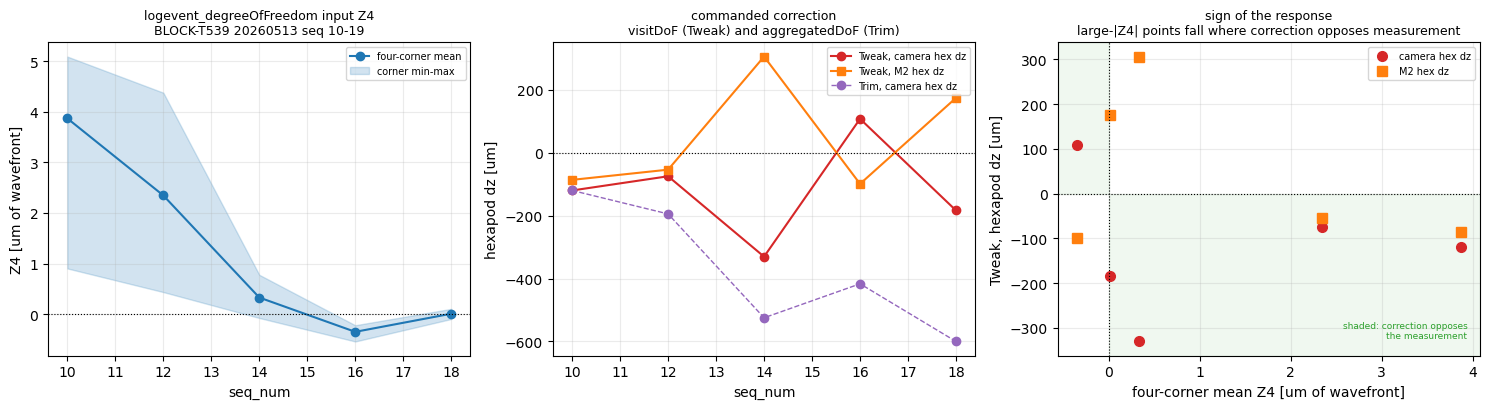

The left panel is the sequence walking into focus: the four-corner mean Z4 falls from 
+3.87 to +0.01 um of wavefront over the five applied corrections.

The third panel carries the sign: both large-|Z4| visits sit in a shaded quadrant, so the
commanded hexapod dz opposes the measured wavefront. No slope is drawn because the
measured-to-commanded gain is not a single number here -- the DOF subset and v-mode
truncation change partway through the sequence.

The small-|Z4| visits (seq_num 14, 16, 18; |Z4| < 0.4 um of wavefront) do NOT all fall in the
shaded quadrants, and are not expected to: once the focus error approaches zero the residual
Z4 is comparable to the corner-to-corner spread, and the correction is then driven by the
other Zernikes and DOF in the fit rather than by defocus. The sign is read from the
large-signal visits, which is the whole reason this block is the right test.


In [23]:
# The gain, checked on the axis that actually carries the focus correction. The Tweak is the
# proportional response to the optical state, so consecutive visits should show the focus error
# shrinking by roughly (1 - kp) per applied correction.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.plot(z4g.index, z4g.z4_mean, 'o-', color='tab:blue', label='four-corner mean')
ax.fill_between(z4g.index, z4g.z4_min, z4g.z4_max, alpha=0.2, color='tab:blue',
                label='corner min-max')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('seq_num'); ax.set_ylabel('Z4 [um of wavefront]')
ax.set_title(f'{DOF_TOPIC.split(".")[-1]} input Z4\n{SIGN_BLOCK} '
             f'{SIGN_DAY_OBS} seq {SIGN_SEQ_MIN}-{SIGN_SEQ_MAX}', fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(t539.seq_num, t539.tweak_cam_dz, 'o-', color='tab:red', label='Tweak, camera hex dz')
ax.plot(t539.seq_num, t539.tweak_m2_dz, 's-', color='tab:orange', label='Tweak, M2 hex dz')
ax.plot(t539.seq_num, t539.trim_cam_dz, 'o--', color='tab:purple', lw=1,
        label='Trim, camera hex dz')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('seq_num'); ax.set_ylabel('hexapod dz [um]')
ax.set_title('commanded correction\nvisitDoF (Tweak) and aggregatedDoF (Trim)', fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(t539.z4_mean, t539.tweak_cam_dz, 'o', color='tab:red', ms=7,
        label='camera hex dz')
ax.plot(t539.z4_mean, t539.tweak_m2_dz, 's', color='tab:orange', ms=7, label='M2 hex dz')
# Shade the two quadrants where the correction OPPOSES the measurement. No fitted or
# predicted slope is drawn: the measured-to-commanded gain depends on the DOF subset and
# v-mode truncation in force, which changes partway through this sequence, so a single
# reference line would misrepresent it. Only the QUADRANT matters for the sign.
ax.axhline(0, color='k', lw=0.8, ls=':'); ax.axvline(0, color='k', lw=0.8, ls=':')
_xl = ax.get_xlim(); _yl = ax.get_ylim()
ax.fill_between([0, _xl[1]], _yl[0], 0, color='tab:green', alpha=0.07, zorder=0)
ax.fill_between([_xl[0], 0], 0, _yl[1], color='tab:green', alpha=0.07, zorder=0)
ax.text(0.97, 0.05, 'shaded: correction opposes\nthe measurement', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=6.5, color='tab:green')
ax.set_xlim(_xl); ax.set_ylim(_yl)
ax.set_xlabel('four-corner mean Z4 [um of wavefront]')
ax.set_ylabel('Tweak, hexapod dz [um]')
ax.set_title('sign of the response\nlarge-|Z4| points fall where correction opposes '
             'measurement', fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT / 'corner_z4_vs_temperature_science_t539_signcheck.png', dpi=130)
plt.show()
print('The left panel is the sequence walking into focus: the four-corner mean Z4 falls from '
      f'\n{z4g.z4_mean.iloc[0]:+.2f} to {z4g.z4_mean.iloc[-1]:+.2f} um of wavefront over the '
      'five applied corrections.')
print('\nThe third panel carries the sign: both large-|Z4| visits sit in a shaded quadrant, so '
      'the\ncommanded hexapod dz opposes the measured wavefront. No slope is drawn because the\n'
      'measured-to-commanded gain is not a single number here -- the DOF subset and v-mode\n'
      'truncation change partway through the sequence.')
print('\nThe small-|Z4| visits (seq_num 14, 16, 18; |Z4| < 0.4 um of wavefront) do NOT all fall '
      'in the\nshaded quadrants, and are not expected to: once the focus error approaches zero '
      'the residual\nZ4 is comparable to the corner-to-corner spread, and the correction is '
      'then driven by the\nother Zernikes and DOF in the fit rather than by defocus. The sign '
      'is read from the\nlarge-signal visits, which is the whole reason this block is the '
      'right test.')


<a id="scatter"></a>
## 9. Scatter against temperature, by band

One row per temperature variable, one panel per band. Each panel carries the Huber slope with
its standard error, Pearson r, Spearman rho, and n. The right-hand axis of the `v1_total`
panels gives the equivalent hexapod dz in µm, through `1 / V1_PER_UM_DZ`.

In [24]:
def scatter_page(ycol, ylabel, fname, secondary=True):
    """Scatter `ycol` against the three temperatures, one panel per band.

    Parameters
    ----------
    ycol : `str`
        Column of `df` to plot on the y axis, dimensionless v-mode-1 amplitude.
    ylabel : `str`
        y-axis label including units.
    fname : `str`
        Output PNG basename, written under `OUT`.
    secondary : `bool`, optional
        Add a right-hand axis in µm of equivalent hexapod dz.

    Returns
    -------
    summary : `pandas.DataFrame`
        One row per (temperature, band) with the fit statistics.
    """
    temps = [('truss', 'mean TMA truss temperature [deg C]'),
             ('ambient', 'outside ambient temperature [deg C]'),
             ('camera', f'{CAMERA_LABEL} [deg C]')]
    rows = []
    fig, axes = plt.subplots(len(temps), len(BANDS), figsize=(4.2 * len(BANDS),
                                                             3.6 * len(temps)),
                             squeeze=False)
    for i, (tcol, tlabel) in enumerate(temps):
        for j, b in enumerate(BANDS):
            ax = axes[i][j]
            sub = df[df.band == b]
            x = sub[tcol].to_numpy(float)
            y = sub[ycol].to_numpy(float)
            ax.plot(x, y, '.', ms=2.5, alpha=0.35, color=BAND_COLORS.get(b, 'k'))
            r = huber_fit(x, y)
            if r:
                xs = np.linspace(np.nanmin(x), np.nanmax(x), 20)
                ax.plot(xs, r['intercept'] + r['slope'] * xs, '-', color='k', lw=1.2)
                ax.set_title(f'{b} band   slope {r["slope"]:+.4f} +/- {r["slope_err"]:.4f} '
                             f'per deg C\nPearson r {r["pearson_r"]:+.3f}   '
                             f'Spearman rho {r["spearman_rho"]:+.3f}   n = {r["n"]}',
                             fontsize=8)
                rows.append(dict(temperature=tcol, band=b, **r))
            else:
                ax.set_title(f'{b} band   too few finite pairs', fontsize=8)
            ax.set_xlabel(tlabel, fontsize=8)
            if j == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            if secondary:
                sec = ax.secondary_yaxis(
                    'right', functions=(lambda v: v / V1_PER_UM_DZ,
                                        lambda v: v * V1_PER_UM_DZ))
                sec.set_ylabel('equiv. hexapod dz [um]', fontsize=6)
                sec.tick_params(labelsize=6)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.25)

    # One robust y range for the whole figure, so the bands are visually comparable: a few
    # extreme outliers otherwise compress the i and r panels against a g-band-driven scale.
    yall = df[ycol].to_numpy(float)
    yall = yall[np.isfinite(yall)]
    if yall.size:
        lo, hi = np.percentile(yall, [0.2, 99.8])
        pad = 0.05 * (hi - lo)
        for row in axes:
            for ax in row:
                ax.set_ylim(lo - pad, hi + pad)
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=110)
    plt.show()
    return pd.DataFrame(rows)

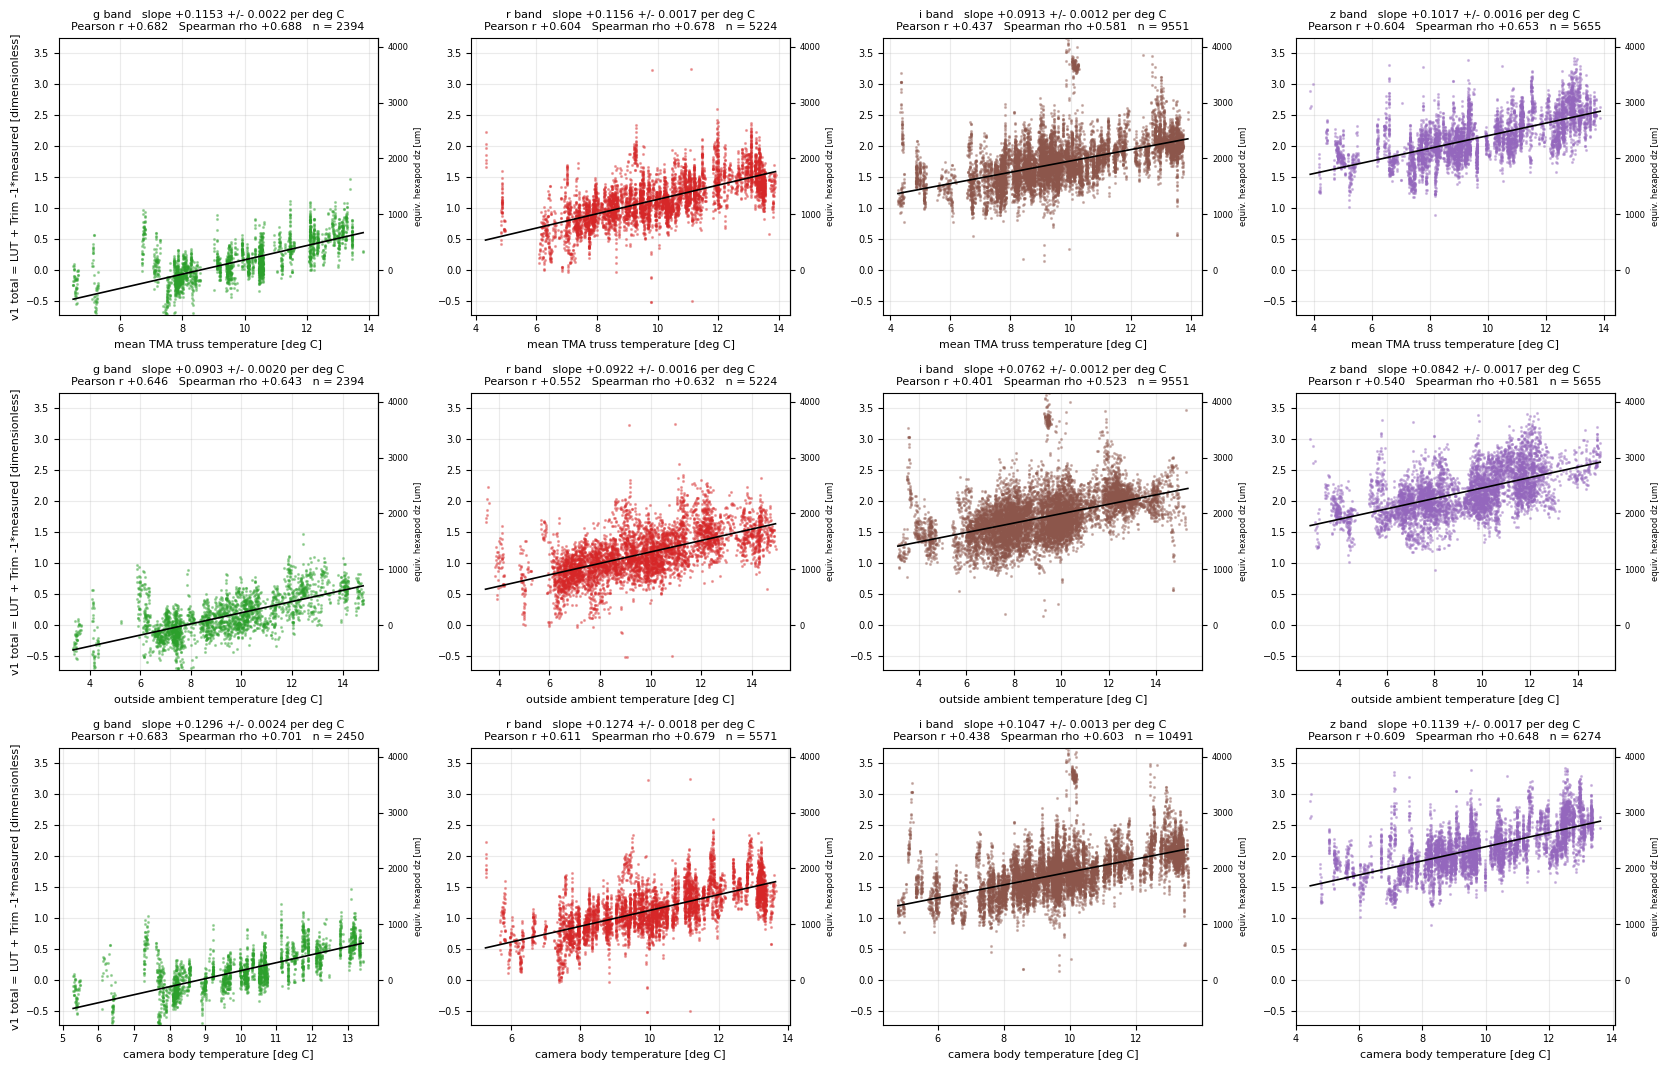

v1_total against temperature, by band:
temperature band     n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
      truss    g  2394 +0.1153    +0.0022    +0.6820       +0.6875     +0.2152
      truss    r  5224 +0.1156    +0.0017    +0.6038       +0.6782     +0.2432
      truss    i  9551 +0.0913    +0.0012    +0.4375       +0.5813     +0.2414
      truss    z  5655 +0.1017    +0.0016    +0.6042       +0.6528     +0.2670
    ambient    g  2394 +0.0903    +0.0020    +0.6458       +0.6425     +0.2310
    ambient    r  5224 +0.0922    +0.0016    +0.5525       +0.6325     +0.2597
    ambient    i  9551 +0.0762    +0.0012    +0.4011       +0.5227     +0.2681
    ambient    z  5655 +0.0842    +0.0017    +0.5404       +0.5806     +0.2848
     camera    g  2450 +0.1296    +0.0024    +0.6831       +0.7012     +0.2137
     camera    r  5571 +0.1274    +0.0018    +0.6109       +0.6787     +0.2437
     camera    i 10491 +0.1047    +0.0013    +0.4382       +0.6033     +0.2383
     camera  

In [25]:
sum_total = scatter_page('v1_total',
                         f'v1 total = LUT + Trim {MEASURED_SIGN:+.0f}*measured [dimensionless]',
                         'corner_z4_vs_temperature_science_v1_total.png')
print('v1_total against temperature, by band:')
print(sum_total[['temperature', 'band', 'n', 'slope', 'slope_err', 'pearson_r',
                 'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))

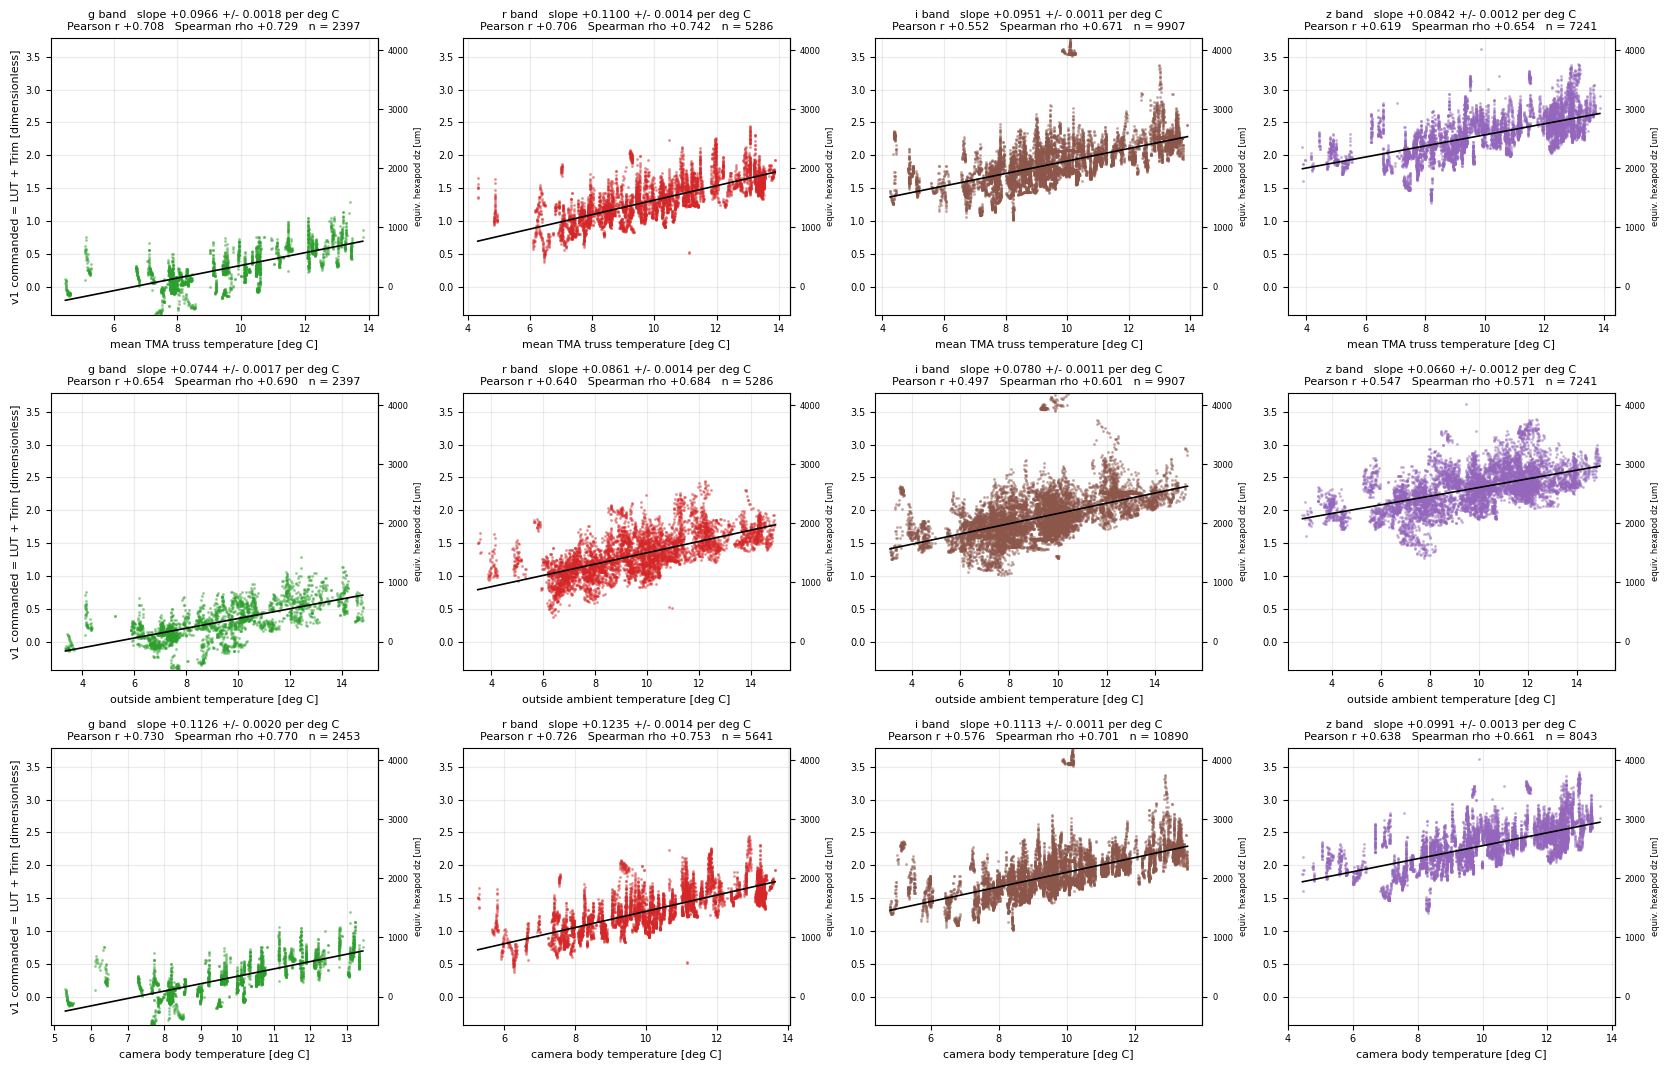

v1(LUT+Trim) against temperature, by band -- compare the truss rows against the FAM result of
+0.09634 per deg C for the lower Trim population in run_dz14_truss.py:
temperature band     n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
      truss    g  2397 +0.0966    +0.0018    +0.7084       +0.7290     +0.1676
      truss    r  5286 +0.1100    +0.0014    +0.7062       +0.7420     +0.2052
      truss    i  9907 +0.0951    +0.0011    +0.5516       +0.6707     +0.2099
      truss    z  7241 +0.0842    +0.0012    +0.6188       +0.6544     +0.2250
    ambient    g  2397 +0.0744    +0.0017    +0.6545       +0.6899     +0.1891
    ambient    r  5286 +0.0861    +0.0014    +0.6397       +0.6839     +0.2236
    ambient    i  9907 +0.0780    +0.0011    +0.4969       +0.6008     +0.2330
    ambient    z  7241 +0.0660    +0.0012    +0.5467       +0.5713     +0.2395
     camera    g  2453 +0.1126    +0.0020    +0.7297       +0.7704     +0.1766
     camera    r  5641 +0.1235    +0.0014    

In [26]:
sum_cmd = scatter_page('v1_lut_trim',
                       'v1 commanded = LUT + Trim [dimensionless]',
                       'corner_z4_vs_temperature_science_v1_lut_trim.png')
print('v1(LUT+Trim) against temperature, by band -- compare the truss rows against the FAM '
      'result of\n+0.09634 per deg C for the lower Trim population in run_dz14_truss.py:')
print(sum_cmd[['temperature', 'band', 'n', 'slope', 'slope_err', 'pearson_r',
               'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))

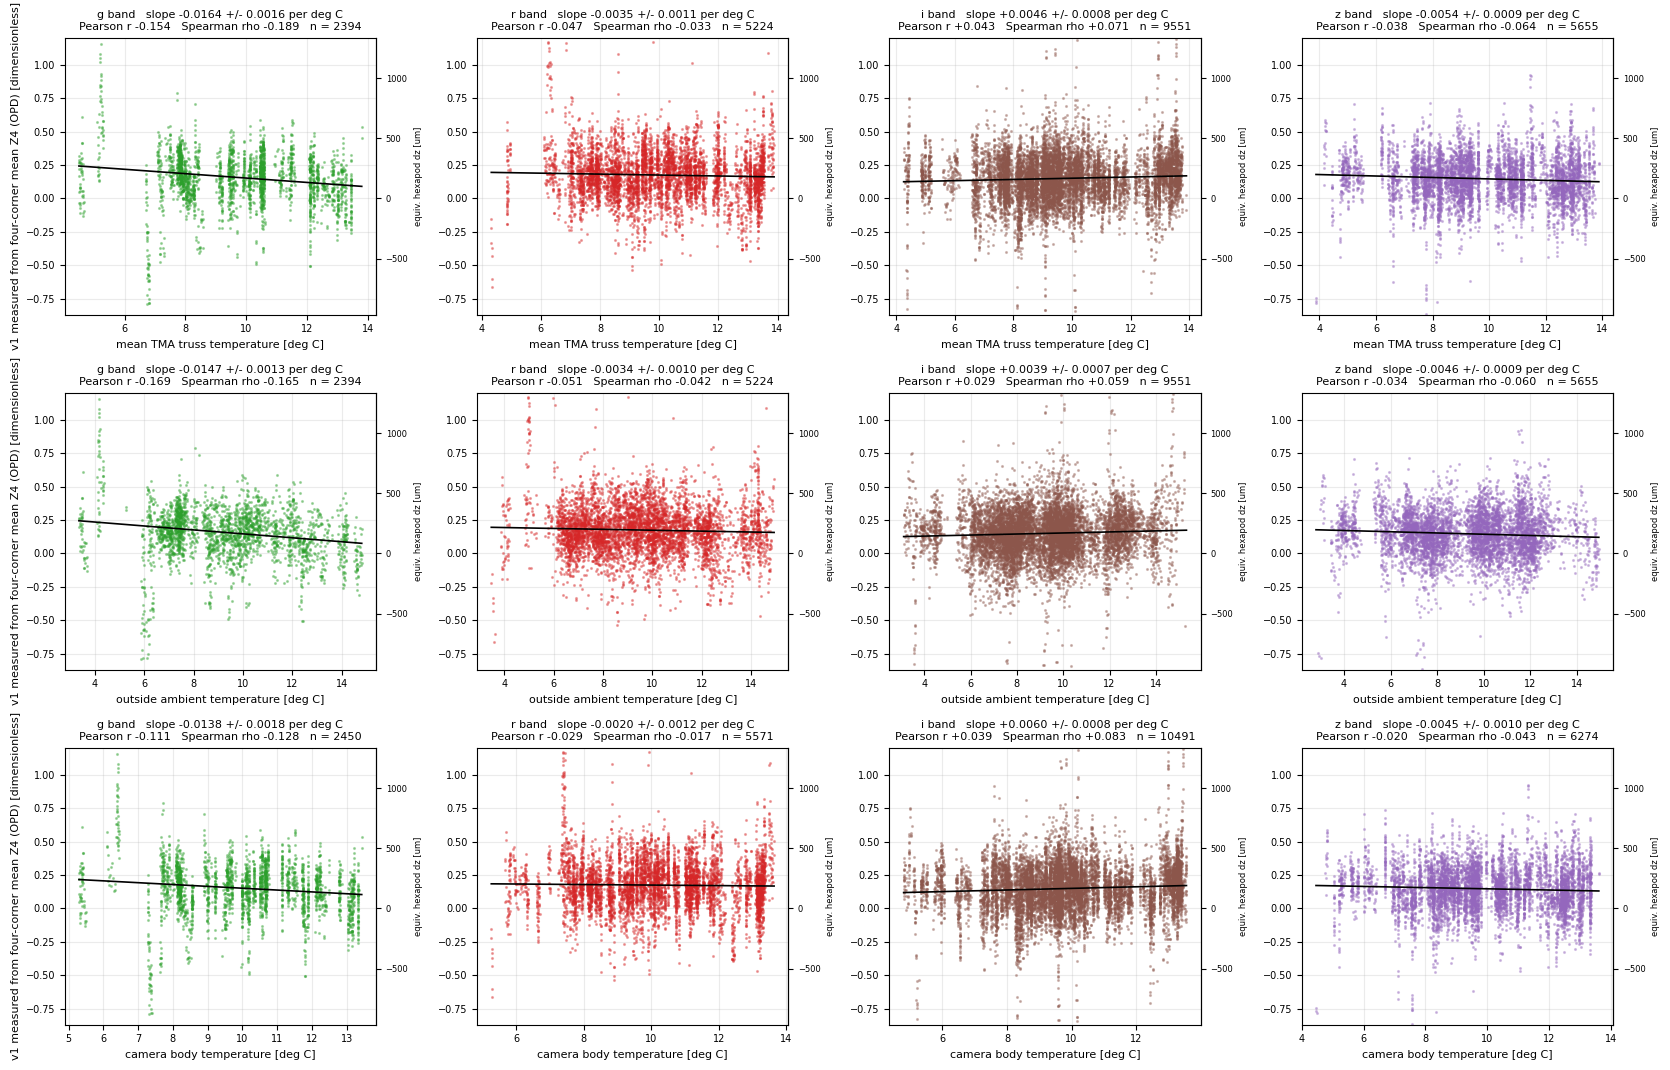

v1 from the four-corner mean Z4 (OPD) alone against temperature, by band:
temperature band     n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
      truss    g  2394 -0.0164    +0.0016    -0.1542       -0.1890     +0.1500
      truss    r  5224 -0.0035    +0.0011    -0.0470       -0.0328     +0.1550
      truss    i  9551 +0.0046    +0.0008    +0.0435       +0.0709     +0.1541
      truss    z  5655 -0.0054    +0.0009    -0.0379       -0.0642     +0.1493
    ambient    g  2394 -0.0147    +0.0013    -0.1692       -0.1647     +0.1513
    ambient    r  5224 -0.0034    +0.0010    -0.0509       -0.0419     +0.1549
    ambient    i  9551 +0.0039    +0.0007    +0.0294       +0.0587     +0.1541
    ambient    z  5655 -0.0046    +0.0009    -0.0340       -0.0604     +0.1493
     camera    g  2450 -0.0138    +0.0018    -0.1111       -0.1282     +0.1540
     camera    r  5571 -0.0020    +0.0012    -0.0292       -0.0167     +0.1572
     camera    i 10491 +0.0060    +0.0008    +0.0390     

In [27]:
sum_meas = scatter_page('v1_meas',
                        'v1 measured from four-corner mean Z4 (OPD) [dimensionless]',
                        'corner_z4_vs_temperature_science_v1_meas.png')
print('v1 from the four-corner mean Z4 (OPD) alone against temperature, by band:')
print(sum_meas[['temperature', 'band', 'n', 'slope', 'slope_err', 'pearson_r',
                'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))

In [28]:
summary = pd.concat([sum_total.assign(quantity='v1_total'),
                     sum_cmd.assign(quantity='v1_lut_trim'),
                     sum_meas.assign(quantity='v1_meas')], ignore_index=True)
pooled = []
for q, col in (('v1_total', 'v1_total'), ('v1_lut_trim', 'v1_lut_trim'),
               ('v1_meas', 'v1_meas')):
    for t in ('truss', 'ambient', 'camera'):
        r = huber_fit(df[t], df[col])
        if r:
            pooled.append(dict(quantity=q, temperature=t, band='all', **r))
pooled = pd.DataFrame(pooled)
summary = pd.concat([summary, pooled], ignore_index=True)
sp = OUT / 'corner_z4_vs_temperature_science_summary.parquet'
summary.to_parquet(sp)
print('all bands pooled:')
print(pooled[['quantity', 'temperature', 'n', 'slope', 'slope_err', 'pearson_r',
              'spearman_rho', 'resid_nmad']].to_string(
    index=False, float_format=lambda v: f'{v:+.4f}'))
print(f'\nsummary written to {sp}')

all bands pooled:
   quantity temperature     n   slope  slope_err  pearson_r  spearman_rho  resid_nmad
   v1_total       truss 22824 +0.0924    +0.0019    +0.2886       +0.3210     +0.5660
   v1_total     ambient 22824 +0.0708    +0.0017    +0.2480       +0.2887     +0.5701
   v1_total      camera 24786 +0.0999    +0.0019    +0.2853       +0.3180     +0.5453
v1_lut_trim       truss 24831 +0.1052    +0.0016    +0.3407       +0.3961     +0.5171
v1_lut_trim     ambient 24831 +0.0820    +0.0015    +0.2963       +0.3558     +0.5259
v1_lut_trim      camera 27027 +0.1157    +0.0017    +0.3401       +0.3958     +0.5004
    v1_meas       truss 22824 -0.0015    +0.0005    -0.0069       -0.0082     +0.1540
    v1_meas     ambient 22824 -0.0017    +0.0005    -0.0158       -0.0162     +0.1540
    v1_meas      camera 24786 +0.0001    +0.0005    +0.0047       +0.0136     +0.1540

summary written to /home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_vs_temperature_scienc

In [29]:
# Equivalent focus sensitivity, for comparison with the thermal cross-check in
# run_dz14_truss.py: 106.9 um of hexapod dz per deg C measured, against 94 um per deg C for a
# 7835 mm steel truss at 12 ppm per deg C.
print(f'{"quantity":14s} {"slope [1/degC]":>16s} {"um hex dz per degC":>20s} '
      f'{"um wavefront per degC":>22s}')
for _, r in pooled[pooled.temperature == 'truss'].iterrows():
    um_per_c = r.slope / V1_PER_UM_DZ
    wf_per_c = um_per_c / abs(DZ_TO_UM)
    print(f'{r.quantity:14s} {r.slope:+16.5f} {um_per_c:+20.1f} {wf_per_c:+22.4f}')
print(f'\nsteel truss reference: {7835.0*1e3*12e-6:.0f} um per deg C '
      f'(7835 mm at 12 ppm per deg C)')

quantity         slope [1/degC]   um hex dz per degC  um wavefront per degC
v1_total               +0.09242               +102.6                +0.0924
v1_lut_trim            +0.10524               +116.8                +0.1052
v1_meas                -0.00150                 -1.7                -0.0015

steel truss reference: 94 um per deg C (7835 mm at 12 ppm per deg C)


<a id="resid"></a>
## 10. Residuals about the truss relation, by band

The Huber fit of `v1_total` against mean TMA truss temperature is subtracted **per band**, so
each band's own slope and intercept are removed. Fitting per band absorbs any band-dependent
focus offset — filter thickness changes the camera-hexapod dz look-up table (LUT) — into the
intercept, rather than leaving it in the residual as four offset clusters.

The residual is dimensionless (v-mode-1 amplitude); the right-hand axis of each panel gives
the equivalent hexapod dz in µm. A Gaussian of the same nMAD is overlaid as a reference for
shape, not as a fitted model: if the residual were purely thermal-plus-noise it would sit
close to that curve, and a heavier tail or a second mode means something else is present.


In [30]:
def truss_residual_per_band(ycol='v1_total', xcol='truss'):
    """Residual of `ycol` about a per-band Huber fit against `xcol`.

    Parameters
    ----------
    ycol : `str`, optional
        Column of `df` to fit, dimensionless v-mode-1 amplitude.
    xcol : `str`, optional
        Predictor column, deg C.

    Returns
    -------
    resid : `numpy.ndarray`
        Residual per row of `df`, dimensionless, NaN where the pair was not finite or the
        band had too few points to fit.
    fits : `dict`
        Band -> the `huber_fit` result dict used for that band.

    Notes
    -----
    Per band rather than pooled: the camera-hexapod dz LUT is filter-dependent, so a pooled
    fit would leave a band-to-band focus offset in the residual.
    """
    resid = np.full(len(df), np.nan)
    fits = {}
    for b in BANDS:
        m = (df.band == b).to_numpy()
        x = df[xcol].to_numpy(float)
        y = df[ycol].to_numpy(float)
        ok = m & np.isfinite(x) & np.isfinite(y)
        r = huber_fit(x[ok], y[ok])
        if r is None:
            continue
        fits[b] = r
        resid[ok] = y[ok] - (r['intercept'] + r['slope'] * x[ok])
    return resid, fits


df['v1_resid_truss'], TRUSS_FITS = truss_residual_per_band()
print(f'{"band":>5s} {"n":>6s} {"slope [1/degC]":>18s} {"intercept":>11s} '
      f'{"resid nMAD":>11s} {"resid nMAD [um dz]":>20s}')
for b in BANDS:
    r = TRUSS_FITS.get(b)
    if r is None:
        print(f'{b:>5s} {"--":>6s}   (too few finite pairs)')
        continue
    print(f'{b:>5s} {r["n"]:6d} {r["slope"]:+11.5f} +/- {r["slope_err"]:.5f} '
          f'{r["intercept"]:+11.4f} {r["resid_nmad"]:11.4f} '
          f'{r["resid_nmad"]/abs(V1_PER_UM_DZ):20.1f}')
_all = df.v1_resid_truss.to_numpy(float)
print(f'\nall bands pooled after per-band subtraction: n = {int(np.isfinite(_all).sum())}, '
      f'median = {np.nanmedian(_all):+.5f}, nMAD = {nmad(_all):.4f} (dimensionless) '
      f'= {nmad(_all)/abs(V1_PER_UM_DZ):.1f} um of equivalent hexapod dz')

# The histogram below shows a one-sided positive tail. Quantify it, rather than leaving it to
# the eye: a symmetric distribution would put equal counts beyond +3 nMAD and -3 nMAD, and a
# Gaussian would put 0.135% in each.
print(f'\n{"band":>5s} {"n":>6s} {"frac > +3 nMAD [%]":>19s} {"frac < -3 nMAD [%]":>19s} '
      f'{"pos/neg ratio":>14s} {"Gaussian [%]":>13s}')
for _b in BANDS:
    _r = df.loc[df.band == _b, 'v1_resid_truss'].to_numpy(float)
    _r = _r[np.isfinite(_r)]
    if len(_r) < 50:
        continue
    _s = nmad(_r)
    _hi = float((_r > 3 * _s).mean()) * 100.0
    _lo = float((_r < -3 * _s).mean()) * 100.0
    _rat = _hi / _lo if _lo > 0 else np.inf
    print(f'{_b:>5s} {len(_r):6d} {_hi:19.2f} {_lo:19.2f} {_rat:14.1f} {0.135:13.3f}')
print('percentages are of that band\'s finite residuals; the Gaussian column is the one-sided\n'
      'expectation for a normal distribution of the same nMAD. An excess that is present on the\n'
      'positive side only is not measurement noise -- it is visits whose commanded focus state\n'
      'sat well above the truss relation.')

# The SAME per-band truss fit, but to the COMMANDED state alone (LUT + Trim, no measured
# wavefront term). The measured term is the noisiest of the three -- it is a four-field-point
# estimate of a field-constant quantity -- so the commanded-only residual isolates the
# within-night focus excursions from the wavefront measurement noise that rides on top of
# them. Both residuals are stored in the Section 13 table so either can be used.
df['v1_resid_truss_lutptrim'], TRUSS_FITS_LUTPTRIM = truss_residual_per_band(
    ycol='v1_lut_trim')
print(f'\n{"-" * 78}\nSame fit against the COMMANDED state only (v1_lut_trim, no measured '
      f'term):\n')
print(f'{"band":>5s} {"n":>6s} {"slope [1/degC]":>18s} {"intercept":>11s} '
      f'{"resid nMAD":>11s} {"resid nMAD [um dz]":>20s}')
for b in BANDS:
    r = TRUSS_FITS_LUTPTRIM.get(b)
    if r is None:
        print(f'{b:>5s} {"--":>6s}   (too few finite pairs)')
        continue
    print(f'{b:>5s} {r["n"]:6d} {r["slope"]:+11.5f} +/- {r["slope_err"]:.5f} '
          f'{r["intercept"]:+11.4f} {r["resid_nmad"]:11.4f} '
          f'{r["resid_nmad"]/abs(V1_PER_UM_DZ):20.1f}')

# How much of the total residual scatter is the measured term? Compare the two nMADs per band.
print(f'\n{"band":>5s} {"nMAD(total) ":>13s} {"nMAD(LUT+Trim)":>15s} {"ratio":>8s}')
for _b in BANDS:
    _rt = TRUSS_FITS.get(_b)
    _rc = TRUSS_FITS_LUTPTRIM.get(_b)
    if _rt is None or _rc is None:
        continue
    print(f'{_b:>5s} {_rt["resid_nmad"]:13.4f} {_rc["resid_nmad"]:15.4f} '
          f'{_rc["resid_nmad"]/_rt["resid_nmad"]:8.3f}')
_at = df.v1_resid_truss.to_numpy(float)
_ac = df.v1_resid_truss_lutptrim.to_numpy(float)
print(f'pooled: nMAD(total) = {nmad(_at):.4f}, nMAD(LUT+Trim) = {nmad(_ac):.4f} '
      f'(both dimensionless)\n'
      f'        = {nmad(_at)/abs(V1_PER_UM_DZ):.1f} and {nmad(_ac)/abs(V1_PER_UM_DZ):.1f} um '
      f'of equivalent hexapod dz\n'
      f'A ratio below 1 means dropping the measured term REDUCES the residual scatter, i.e.\n'
      f'the measured term is contributing more noise than it removes at this level.')


 band      n     slope [1/degC]   intercept  resid nMAD   resid nMAD [um dz]
    g   2394    +0.11529 +/- 0.00218     -0.9873      0.2152                238.8
    r   5224    +0.11564 +/- 0.00170     -0.0155      0.2432                270.0
    i   9551    +0.09135 +/- 0.00125     +0.8482      0.2414                267.9
    z   5655    +0.10171 +/- 0.00164     +1.1521      0.2670                296.3

all bands pooled after per-band subtraction: n = 22824, median = -0.00780, nMAD = 0.2450 (dimensionless) = 271.9 um of equivalent hexapod dz

 band      n  frac > +3 nMAD [%]  frac < -3 nMAD [%]  pos/neg ratio  Gaussian [%]
    g   2394                2.38                0.25            9.5         0.135
    r   5224                2.01                0.38            5.2         0.135
    i   9551                3.04                0.34            9.1         0.135
    z   5655                0.88                0.04           25.0         0.135
percentages are of that band's finite resi

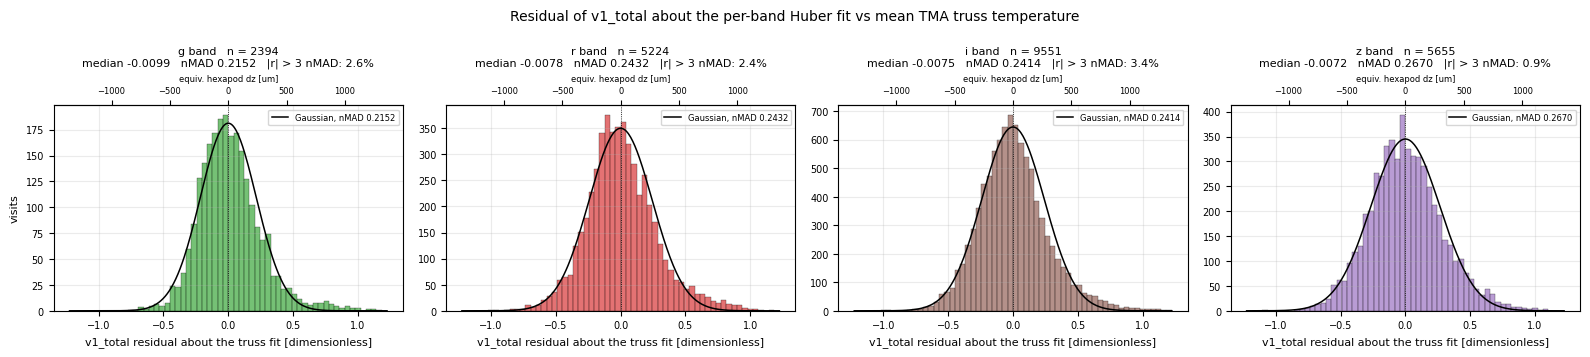

In [31]:
fig, axes = plt.subplots(1, len(BANDS), figsize=(4.0 * len(BANDS), 3.6), squeeze=False)
# One common x range from the pooled robust spread, so the four bands are comparable by eye.
_p = df.v1_resid_truss.to_numpy(float)
_p = _p[np.isfinite(_p)]
_lim = 5.0 * nmad(_p)
_bins = np.linspace(-_lim, _lim, 61)

for j, b in enumerate(BANDS):
    ax = axes[0][j]
    v = df.loc[df.band == b, 'v1_resid_truss'].to_numpy(float)
    v = v[np.isfinite(v)]
    if v.size < 10:
        ax.set_title(f'{b} band   too few points', fontsize=9)
        continue
    ax.hist(v, bins=_bins, color=BAND_COLORS.get(b, 'k'), alpha=0.65,
            edgecolor='k', linewidth=0.3)
    s = nmad(v)
    # Reference Gaussian of the same robust width, scaled to the histogram area. Not a fit.
    xs = np.linspace(-_lim, _lim, 300)
    ax.plot(xs, v.size * (_bins[1] - _bins[0]) * np.exp(-0.5 * (xs / s) ** 2)
            / (s * np.sqrt(2 * np.pi)), 'k-', lw=1.1,
            label=f'Gaussian, nMAD {s:.4f}')
    ax.axvline(0.0, color='k', lw=0.6, ls=':')
    _med, _frac = np.median(v), float(np.mean(np.abs(v) > 3 * s))
    ax.set_title(f'{b} band   n = {v.size}\nmedian {_med:+.4f}   nMAD {s:.4f}   '
                 f'|r| > 3 nMAD: {100 * _frac:.1f}%', fontsize=8)
    ax.set_xlabel('v1_total residual about the truss fit [dimensionless]', fontsize=8)
    if j == 0:
        ax.set_ylabel('visits', fontsize=8)
    sec = ax.secondary_xaxis('top', functions=(lambda v: v / V1_PER_UM_DZ,
                                               lambda v: v * V1_PER_UM_DZ))
    sec.set_xlabel('equiv. hexapod dz [um]', fontsize=6)
    sec.tick_params(labelsize=6)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.grid(alpha=0.25)

fig.suptitle('Residual of v1_total about the per-band Huber fit vs mean TMA truss '
             'temperature', fontsize=10)
fig.tight_layout()
fig.savefig(OUT / 'corner_z4_v1_resid_truss_hist_by_band.png', dpi=110)
plt.show()


<a id="thermalml"></a>
## 11. Does any other thermal channel add information beyond the truss?

The mean TMA truss temperature is the single best physical candidate for the thermal driver of
focus, and Section 9 measures its relation to `v1_total`. This section asks whether the rest of
the thermal telemetry carries **additional** predictive information, or is merely redundant with
the truss.

Ten thermal channels, the `CORE_THERMAL` set used for the Full Array Mode (FAM)
`visits.parquet`, plus the camera-body `AverageTemp` from `lsst.MTCamera`:

| channel | quantity |
|---|---|
| `tma_truss_temp_pxpy`, `tma_truss_temp_mxmy` | TMA truss, +X+Y and −X−Y (their mean is the baseline predictor) |
| `cam_air_temp`, `m2_air_temp`, `m1m3_air_temp`, `outside_temp` | Environmental Sensor Suite (ESS) air temperatures |
| `m2_delta_t`, `cam_m1m3_delta_t`, `dome_delta_t` | derived air-temperature differences against M1M3 |
| `cam_AverageTemp` | camera **body**, from `lsst.MTCamera.utiltrunk_body` |

**Three models, one baseline.** All are scored out-of-sample against the same folds:

1. **baseline** — ordinary least squares on mean truss temperature alone (one predictor);
2. **ridge** — a linear model on all ten channels, standardized, with the regularization
   strength chosen inside each training fold;
3. **gradient boosting** — histogram gradient-boosted trees, to catch nonlinearity or
   interaction that the linear models cannot express.

**The folds are grouped by `day_obs`.** Thermal state is strongly correlated within a night, so
a random split would put near-duplicate rows on both sides and inflate every score — including
the baseline's. Grouping by night makes the question "does this generalize to a night the model
has never seen", which is the question that matters. Each band is modelled separately, matching
the per-band fits used elsewhere.

The reported quantity is out-of-sample R² (dimensionless, fraction of variance explained) and
the **gain over the baseline**. Permutation importance is computed on the held-out fold, so a
channel scores only if it helps predict nights the model did not train on.


In [32]:
def thermal_ml_by_band(ycol='v1_total', features=None, verbose=True):
    """Out-of-sample R2 for truss-only, ridge and gradient boosting, per band.

    Parameters
    ----------
    ycol : `str`, optional
        Target column of `df`, dimensionless v-mode-1 amplitude.
    features : `list` of `str`, optional
        Thermal predictor columns, deg C. Defaults to `CORE_THERMAL`.
    verbose : `bool`, optional
        Print the per-band table as it goes.

    Returns
    -------
    scores : `pandas.DataFrame`
        One row per band with ``n``, ``n_nights`` and the out-of-sample R2 of each model
        (all dimensionless), plus the gain of each over the truss-only baseline.
    importance : `pandas.DataFrame`
        Permutation importance per (band, channel), as the mean drop in R2 on the held-out
        fold, dimensionless.

    Notes
    -----
    Folds are `GroupKFold` on ``day_obs``: thermal state is correlated within a night, so an
    ungrouped split leaks it and inflates every score. Rows with any non-finite feature or
    target are dropped, so all three models see exactly the same rows.
    """
    features = list(CORE_THERMAL if features is None else features)
    rows, imps = [], []
    for b in BANDS:
        sub = df[df.band == b]
        cols = [c for c in features if c in sub.columns]
        M = sub[cols + [ycol, 'truss', 'day_obs']].to_numpy(float)
        ok = np.isfinite(M).all(axis=1)
        sub = sub[ok]
        if len(sub) < 50 or sub.day_obs.nunique() < ML_N_SPLITS:
            if verbose:
                print(f'{b} band: only n = {len(sub)} complete rows over '
                      f'{sub.day_obs.nunique()} nights -- skipped')
            continue
        X = sub[cols].to_numpy(float)
        y = sub[ycol].to_numpy(float)
        xt = sub[['truss']].to_numpy(float)
        groups = sub.day_obs.to_numpy()
        n_splits = min(ML_N_SPLITS, sub.day_obs.nunique())
        gkf = GroupKFold(n_splits=n_splits)

        # Accumulate predictions across folds, then score once: per-fold R2 averaging is
        # unstable when the folds differ in size and in thermal range.
        pred = {k: np.full(len(sub), np.nan) for k in ('base', 'ridge', 'gb')}
        imp_acc = []
        for tr, te in gkf.split(X, y, groups):
            b0 = make_pipeline(StandardScaler(), RidgeCV(alphas=[1e-8]))
            b0.fit(xt[tr], y[tr])
            pred['base'][te] = b0.predict(xt[te])

            rg = make_pipeline(StandardScaler(), RidgeCV(alphas=ML_ALPHAS))
            rg.fit(X[tr], y[tr])
            pred['ridge'][te] = rg.predict(X[te])

            gb = HistGradientBoostingRegressor(
                max_iter=ML_GB_PARAMS['n_estimators'],
                max_depth=ML_GB_PARAMS['max_depth'],
                learning_rate=ML_GB_PARAMS['learning_rate'],
                random_state=ML_GB_PARAMS['random_state'])
            gb.fit(X[tr], y[tr])
            pred['gb'][te] = gb.predict(X[te])

            pi = permutation_importance(gb, X[te], y[te], n_repeats=ML_N_PERM,
                                        random_state=ML_RANDOM_STATE,
                                        scoring='r2')
            imp_acc.append(pi.importances_mean)

        def _r2(yhat):
            m = np.isfinite(yhat)
            ss_res = np.sum((y[m] - yhat[m]) ** 2)
            ss_tot = np.sum((y[m] - np.mean(y[m])) ** 2)
            return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

        r2 = {k: _r2(v) for k, v in pred.items()}
        rows.append(dict(band=b, n=len(sub), n_nights=int(sub.day_obs.nunique()),
                         n_splits=n_splits,
                         r2_truss_only=r2['base'], r2_ridge_all=r2['ridge'],
                         r2_gb_all=r2['gb'],
                         gain_ridge=r2['ridge'] - r2['base'],
                         gain_gb=r2['gb'] - r2['base']))
        mean_imp = np.mean(np.vstack(imp_acc), axis=0)
        for c, v in zip(cols, mean_imp):
            imps.append(dict(band=b, channel=c, importance=float(v)))
        if verbose:
            print(f'{b} band: n = {len(sub)}, {sub.day_obs.nunique()} nights, '
                  f'{n_splits} folds -> R2 truss {r2["base"]:+.4f}, '
                  f'ridge {r2["ridge"]:+.4f}, GB {r2["gb"]:+.4f}')
    return pd.DataFrame(rows), pd.DataFrame(imps)


ml_scores, ml_imp = thermal_ml_by_band()
print('\nOut-of-sample R2 (dimensionless, grouped by day_obs), and gain over truss-only:')
print(ml_scores.round(4).to_string(index=False))


g band: n = 2202, 34 nights, 5 folds -> R2 truss +0.3898, ridge +0.4759, GB +0.2501
r band: n = 4992, 41 nights, 5 folds -> R2 truss +0.3545, ridge +0.3932, GB +0.2964
i band: n = 9397, 44 nights, 5 folds -> R2 truss +0.1603, ridge +0.1381, GB -0.0181
z band: n = 5653, 41 nights, 5 folds -> R2 truss +0.3255, ridge +0.3952, GB +0.2236

Out-of-sample R2 (dimensionless, grouped by day_obs), and gain over truss-only:
band    n  n_nights  n_splits  r2_truss_only  r2_ridge_all  r2_gb_all  gain_ridge  gain_gb
   g 2202        34         5         0.3898        0.4759     0.2501      0.0861  -0.1396
   r 4992        41         5         0.3545        0.3932     0.2964      0.0387  -0.0582
   i 9397        44         5         0.1603        0.1381    -0.0181     -0.0222  -0.1784
   z 5653        41         5         0.3255        0.3952     0.2236      0.0697  -0.1019


truss-only R2 across bands: +0.3075 mean, 0.0880 std (dimensionless, n = 4 bands)
gain from all 10 channels, ridge: +0.0431 mean, range -0.0222 to +0.0861
gain from all 10 channels, GB   : -0.1195 mean, range -0.1784 to -0.0582

Every band improves with both models: False. A gain that is positive in some bands
and negative in others is fold noise, not information.

 band   nMAD resid, truss only   nMAD resid, GB all    ratio
    g                   0.2152               0.2385    1.109
    r                   0.2432               0.2540    1.044
    i                   0.2414               0.2658    1.101
    z                   0.2670               0.2864    1.073
(ratio is dimensionless, sqrt of the unexplained-variance ratio; below 1 means GB predicts better)

Permutation importance on the held-out fold (mean drop in R2, dimensionless):
band                      g       i       r       z    mean
channel                                                    
cam_AverageTemp      0.3840  

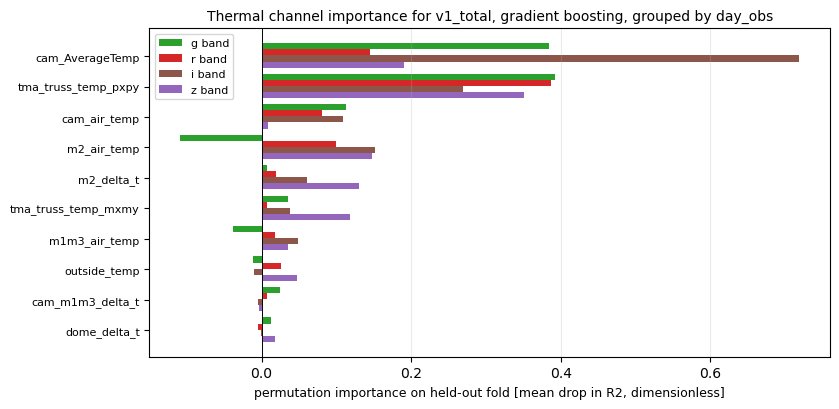

In [33]:
# Is the gain worth anything? Compare it to the spread of the baseline R2 across bands: a gain
# smaller than that spread is not evidence of extra information.
if len(ml_scores):
    _b = ml_scores.r2_truss_only.to_numpy(float)
    _gr = ml_scores.gain_ridge.to_numpy(float)
    _gg = ml_scores.gain_gb.to_numpy(float)
    print(f'truss-only R2 across bands: {np.mean(_b):+.4f} mean, '
          f'{np.std(_b):.4f} std (dimensionless, n = {len(_b)} bands)')
    print(f'gain from all 10 channels, ridge: {np.mean(_gr):+.4f} mean, '
          f'range {np.min(_gr):+.4f} to {np.max(_gr):+.4f}')
    print(f'gain from all 10 channels, GB   : {np.mean(_gg):+.4f} mean, '
          f'range {np.min(_gg):+.4f} to {np.max(_gg):+.4f}')
    _consistent = bool(np.all(_gg > 0)) and bool(np.all(_gr > 0))
    print(f'\nEvery band improves with both models: {_consistent}. A gain that is positive in '
          f'some bands\nand negative in others is fold noise, not information.')

    # Residual scatter, the same quantity Section 10 reports, so the two are comparable.
    print(f'\n{"band":>5s} {"nMAD resid, truss only":>24s} {"nMAD resid, GB all":>20s} '
          f'{"ratio":>8s}')
    for _, r in ml_scores.iterrows():
        _f = np.sqrt(max(1e-12, 1 - r.r2_gb_all) / max(1e-12, 1 - r.r2_truss_only))
        _n0 = TRUSS_FITS.get(r.band, {}).get('resid_nmad', np.nan)
        print(f'{r.band:>5s} {_n0:24.4f} {_n0 * _f:20.4f} {_f:8.3f}')
    print('(ratio is dimensionless, sqrt of the unexplained-variance ratio; '
          'below 1 means GB predicts better)')

# Permutation importance, averaged over folds and bands: which channels actually carry signal.
if len(ml_imp):
    piv = (ml_imp.pivot(index='channel', columns='band', values='importance')
           .reindex(CORE_THERMAL))
    piv['mean'] = piv.mean(axis=1)
    piv = piv.sort_values('mean', ascending=False)
    print('\nPermutation importance on the held-out fold '
          '(mean drop in R2, dimensionless):')
    print(piv.round(4).to_string())

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    _o = piv.drop(columns='mean')
    _y = np.arange(len(_o))
    for j, b in enumerate([c for c in BANDS if c in _o.columns]):
        ax.barh(_y + 0.8 * (j / max(1, len(_o.columns)) - 0.4), _o[b].to_numpy(float),
                height=0.8 / max(1, len(_o.columns)),
                color=BAND_COLORS.get(b, 'k'), label=f'{b} band')
    ax.set_yticks(_y)
    ax.set_yticklabels(_o.index, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0.0, color='k', lw=0.7)
    ax.set_xlabel('permutation importance on held-out fold '
                  '[mean drop in R2, dimensionless]', fontsize=9)
    ax.set_title('Thermal channel importance for v1_total, gradient boosting, '
                 'grouped by day_obs', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25, axis='x')
    fig.tight_layout()
    fig.savefig(OUT / 'corner_z4_thermal_ml_importance.png', dpi=110)
    plt.show()


<a id="timehist"></a>
## 12. Time history of the thermal residual within a night

The question here is whether the part of `v1_total` that the truss temperature does **not**
explain drifts in a consistent way as a night progresses. If every night showed the same trend
against time-since-start, that would point to a systematic the truss relation is missing — a
thermal lag, a settling transient, or something that simply tracks elapsed time.

The residual is the same `v1_resid_truss` from Section 10: `v1_total` minus its **per-band**
Huber fit against mean truss temperature. Only the truss is used as the thermal predictor here;
if Section 11 shows a large improvement from the other channels, this should be revisited using
the better model's residual instead.

Two zero points per night, because they answer different questions:

- **(a) zero-degree evening twilight** — the moment the sun's geometric altitude passes
  −0.0° going down, computed from the site coordinates. Depends only on sun geometry and the
  date, so it aligns nights by *solar* time regardless of what was actually observed. This is
  the right zero point for a thermal effect driven by sunset.
- **(b) the first science or acquisition exposure of the night** — when imaging actually
  started. This aligns nights by *operational* time, and absorbs the fact that the observing
  start time relative to twilight varies from night to night.

A drift that is consistent against (a) but not (b) is tied to sunset; consistent against (b)
but not (a) is tied to the start of operations. The last cell plots the UTC clock time of both
zero points per night, as the validation that each was computed correctly.

Each panel carries three things: one faint line per `day_obs`, the pooled Huber fit, and — the
one to read — the **median across nights in one-hour bins**, with an error bar of
nMAD/sqrt(n_nights). The per-night lines are too noisy visit-to-visit to read a shape from;
the binned median asks the question directly, namely where the residual sits at a given hour
into the night once the nights are averaged. A consistent drift would appear as a sloped curve
lying well outside those error bars.


In [39]:
RUBIN_SITE = EarthLocation(lat=RUBIN_LAT_DEG * u.deg, lon=RUBIN_LON_DEG * u.deg,
                           height=RUBIN_HEIGHT_M * u.m)


def evening_twilight_mjd(day_obs, sun_alt_deg=TWILIGHT_SUN_ALT_DEG):
    """MJD (UTC) of evening twilight for one ``day_obs``, at a given sun altitude.

    Parameters
    ----------
    day_obs : `int`
        Observing night, YYYYMMDD. By Rubin convention the night labelled ``day_obs`` starts
        on the evening of that calendar date, so the descending sun crossing is sought on
        that date.
    sun_alt_deg : `float`, optional
        Geometric sun altitude defining twilight, deg. Defaults to `TWILIGHT_SUN_ALT_DEG`
        (0.0 deg, "zero-degree twilight").

    Returns
    -------
    mjd : `float`
        MJD in UTC of the descending crossing, or NaN if none was bracketed.

    Notes
    -----
    Coarse scan on a 2-minute grid over the evening, then a bisection to about 1 s. The
    altitude used is geometric — no refraction correction — which is what "zero-degree" is
    normally taken to mean here; refraction would move the crossing by roughly 2 minutes.
    """
    d = str(int(day_obs))
    t0 = Time(f'{d[:4]}-{d[4:6]}-{d[6:]}T16:00:00', scale='utc')   # ~13:00 local, pre-sunset
    grid = t0 + TimeDelta(np.arange(0, 12 * 60, 2.0) * 60.0, format='sec')
    alt = get_sun(grid).transform_to(AltAz(obstime=grid, location=RUBIN_SITE)).alt.deg
    below = alt - sun_alt_deg
    # first descending sign change: positive (sun up) -> negative (sun down)
    idx = np.nonzero((below[:-1] > 0) & (below[1:] <= 0))[0]
    if not len(idx):
        return np.nan
    lo, hi = grid[idx[0]], grid[idx[0] + 1]
    for _ in range(24):                       # 2 min / 2^24 is far below 1 s
        mid = lo + (hi - lo) / 2
        a = get_sun(mid).transform_to(AltAz(obstime=mid, location=RUBIN_SITE)).alt.deg
        if a - sun_alt_deg > 0:
            lo = mid
        else:
            hi = mid
    return float((lo + (hi - lo) / 2).utc.mjd)


# (a) twilight per night
nights = sorted(df.day_obs.unique())
twi = {int(d): evening_twilight_mjd(int(d)) for d in nights}
print(f'zero-degree twilight computed for {sum(np.isfinite(list(twi.values())))} '
      f'of {len(nights)} nights')

# (b) first science-or-acq exposure per night. Queried from ConsDB rather than taken from
# `df`, because `df` holds only g/r/i/z science visits -- the true first image of the night is
# often an `acq` frame, or a science frame in another band.
_types = ', '.join(f"'{t}'" for t in FIRST_IMG_TYPES)
q_first = (f"SELECT day_obs, MIN(exp_midpt_mjd) AS first_mjd "
           f"FROM cdb_{INSTRUMENT}.visit1 "
           f"WHERE day_obs BETWEEN {DAY_OBS_MIN} AND {DAY_OBS_MAX} "
           f"  AND img_type IN ({_types}) "
           f"GROUP BY day_obs ORDER BY day_obs")
first_df = cdb.query(q_first).to_pandas()
first_df['day_obs'] = first_df.day_obs.astype(int)
first_mjd = dict(zip(first_df.day_obs, first_df.first_mjd.astype(float)))
print(f'first {"/".join(FIRST_IMG_TYPES)} exposure found for {len(first_mjd)} nights')

df['mjd0_twilight'] = df.day_obs.map(twi).astype(float)
df['mjd0_firstimg'] = df.day_obs.map(first_mjd).astype(float)
df['hours_since_twilight'] = (df.exp_midpt_mjd - df.mjd0_twilight) * 24.0
df['hours_since_firstimg'] = (df.exp_midpt_mjd - df.mjd0_firstimg) * 24.0

for _c, _lab in (('hours_since_twilight', 'since zero-degree twilight'),
                 ('hours_since_firstimg', f'since first {FIRST_IMG_TYPES[0]}/{FIRST_IMG_TYPES[1]}')):
    _v = df[_c].to_numpy(float)
    print(f'{_lab:38s}: n = {np.isfinite(_v).sum():6d}, '
          f'median = {np.nanmedian(_v):+6.2f} h, '
          f'range = {np.nanmin(_v):+6.2f} to {np.nanmax(_v):+6.2f} h')

# The offset between the two zero points is itself informative: it is how long after twilight
# imaging actually began, per night.
_off = (df.groupby('day_obs')
        .agg(twi=('mjd0_twilight', 'first'), fst=('mjd0_firstimg', 'first')))
_off['delay_h'] = (_off.fst - _off.twi) * 24.0
print(f'\nfirst image minus twilight: median {_off.delay_h.median():+.2f} h, '
      f'range {_off.delay_h.min():+.2f} to {_off.delay_h.max():+.2f} h '
      f'(n = {int(_off.delay_h.notna().sum())} nights)')


zero-degree twilight computed for 52 of 52 nights
first science/acq exposure found for 55 nights
since zero-degree twilight            : n =  27671, median =  +7.42 h, range =  +0.98 to +12.93 h
since first science/acq               : n =  27671, median =  +5.99 h, range =  +0.14 to +12.07 h

first image minus twilight: median +0.99 h, range +0.75 to +5.26 h (n = 52 nights)


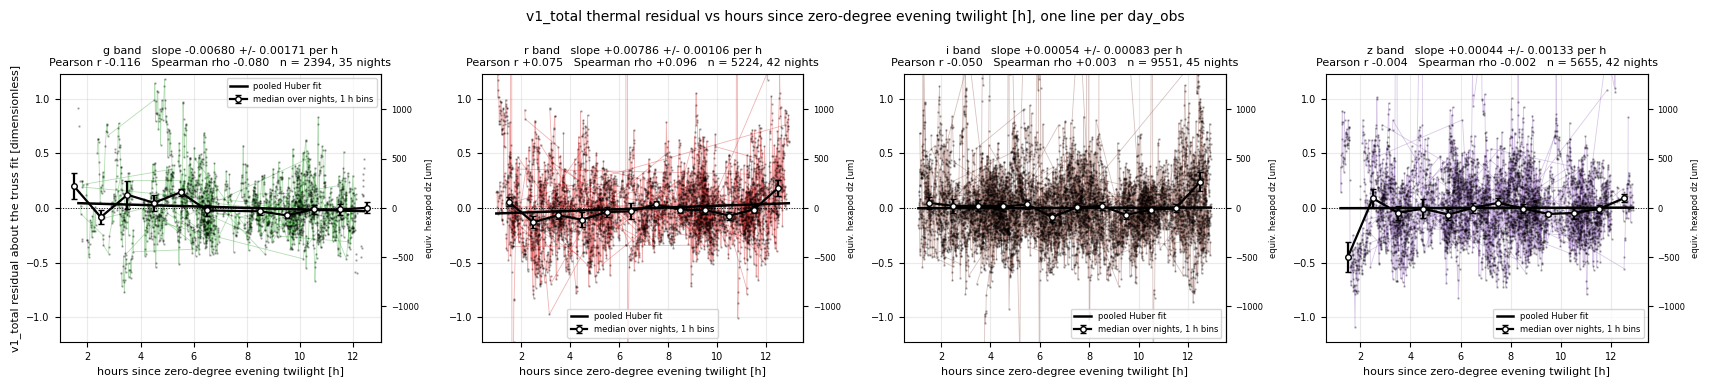

(a) aligned on zero-degree twilight:
band    n  n_nights  slope_per_hour  slope_err  pearson_r  spearman_rho  median_night_slope  nmad_night_slope
   g 2394        35        -0.00680    0.00171   -0.11580      -0.07972             0.01310           0.08364
   r 5224        42         0.00786    0.00106    0.07475       0.09643             0.00023           0.04161
   i 9551        45         0.00054    0.00083   -0.05034       0.00269             0.00517           0.04615
   z 5655        42         0.00044    0.00133   -0.00414      -0.00151             0.01220           0.07899


In [40]:
def time_history_page(xcol, xlabel, fname, max_nights_labeled=0):
    """Residual time history, one panel per band, with a line per ``day_obs``.

    Parameters
    ----------
    xcol : `str`
        Column of `df` holding hours since that night's zero point.
    xlabel : `str`
        x-axis label including units.
    fname : `str`
        Output PNG basename, written under `OUT`.
    max_nights_labeled : `int`, optional
        Number of nights to name in a legend; 0 means none, which is the sane default for
        the ~60-night range here.

    Returns
    -------
    trend : `pandas.DataFrame`
        Per band, the Huber slope of the residual against `xcol` (dimensionless per hour),
        pooled over nights, plus the median per-night slope.
    """
    rows = []
    fig, axes = plt.subplots(1, len(BANDS), figsize=(4.3 * len(BANDS), 3.9), squeeze=False)
    for j, b in enumerate(BANDS):
        ax = axes[0][j]
        sub = df[(df.band == b) & np.isfinite(df[xcol]) & np.isfinite(df.v1_resid_truss)]
        # one faint line per night, so a consistent shape shows up as a bundle
        night_slopes = []
        for d, g in sub.groupby('day_obs'):
            g = g.sort_values(xcol)
            if len(g) < MIN_PTS_PER_NIGHT:      # huber_fit itself needs 10 finite pairs
                continue
            ax.plot(g[xcol], g.v1_resid_truss, '-', lw=0.6, alpha=0.35,
                    color=BAND_COLORS.get(b, 'k'))
            rn = huber_fit(g[xcol], g.v1_resid_truss)
            if rn:
                night_slopes.append(rn['slope'])
        ax.plot(sub[xcol], sub.v1_resid_truss, '.', ms=1.6, alpha=0.25, color='k')

        # Median across nights in fixed time bins, with a nMAD/sqrt(n_nights) error bar. The
        # per-night lines above are too noisy visit-to-visit to read a shape from; this asks
        # the direct question -- at a given hour into the night, where does the residual sit,
        # averaged over nights? A consistent drift appears here as a sloped curve well
        # outside the error bars.
        edges = np.arange(np.floor(np.nanmin(sub[xcol])), np.ceil(np.nanmax(sub[xcol])) + 1e-9,
                          TIME_BIN_H)
        if len(edges) > 2:
            per_night = (sub.assign(_b=pd.cut(sub[xcol], edges, labels=False))
                         .groupby(['_b', 'day_obs']).v1_resid_truss.median())
            gb = per_night.groupby('_b')
            ctr = 0.5 * (edges[:-1] + edges[1:])
            bi = gb.median().index.to_numpy().astype(int)
            med = gb.median().to_numpy()
            nn = gb.size().to_numpy()
            err = np.array([nmad(v.to_numpy()) for _, v in gb]) / np.sqrt(np.maximum(nn, 1))
            keep = nn >= MIN_NIGHTS_PER_BIN
            ax.errorbar(ctr[bi][keep], med[keep], yerr=err[keep], fmt='o-', ms=4, lw=1.6,
                        color='k', mfc='w', capsize=2, zorder=5,
                        label=f'median over nights, {TIME_BIN_H:.0f} h bins')

        r = huber_fit(sub[xcol], sub.v1_resid_truss)
        if r:
            xs = np.linspace(np.nanmin(sub[xcol]), np.nanmax(sub[xcol]), 20)
            ax.plot(xs, r['intercept'] + r['slope'] * xs, 'k-', lw=1.8,
                    label='pooled Huber fit')
            rows.append(dict(band=b, n=r['n'], n_nights=int(sub.day_obs.nunique()),
                             slope_per_hour=r['slope'], slope_err=r['slope_err'],
                             pearson_r=r['pearson_r'], spearman_rho=r['spearman_rho'],
                             median_night_slope=(float(np.median(night_slopes))
                                                 if night_slopes else np.nan),
                             nmad_night_slope=(float(nmad(np.array(night_slopes)))
                                               if len(night_slopes) > 2 else np.nan)))
            ax.set_title(f'{b} band   slope {r["slope"]:+.5f} +/- {r["slope_err"]:.5f} '
                         f'per h\nPearson r {r["pearson_r"]:+.3f}   '
                         f'Spearman rho {r["spearman_rho"]:+.3f}   n = {r["n"]}, '
                         f'{sub.day_obs.nunique()} nights', fontsize=8)
        ax.axhline(0.0, color='k', lw=0.7, ls=':')
        ax.set_xlabel(xlabel, fontsize=8)
        if j == 0:
            ax.set_ylabel('v1_total residual about the truss fit [dimensionless]',
                          fontsize=8)
        sec = ax.secondary_yaxis('right', functions=(lambda v: v / V1_PER_UM_DZ,
                                                     lambda v: v * V1_PER_UM_DZ))
        sec.set_ylabel('equiv. hexapod dz [um]', fontsize=6)
        sec.tick_params(labelsize=6)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)
        ax.grid(alpha=0.25)

    # common robust y range across bands
    _p = df.v1_resid_truss.to_numpy(float)
    _p = _p[np.isfinite(_p)]
    _lim = 5.0 * nmad(_p)
    for row in axes:
        for ax in row:
            ax.set_ylim(-_lim, _lim)
    fig.suptitle(f'v1_total thermal residual vs {xlabel}, one line per day_obs', fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=110)
    plt.show()
    return pd.DataFrame(rows)


trend_twi = time_history_page('hours_since_twilight',
                              'hours since zero-degree evening twilight [h]',
                              'corner_z4_v1_resid_vs_hours_since_twilight.png')
print('(a) aligned on zero-degree twilight:')
print(trend_twi.round(5).to_string(index=False))


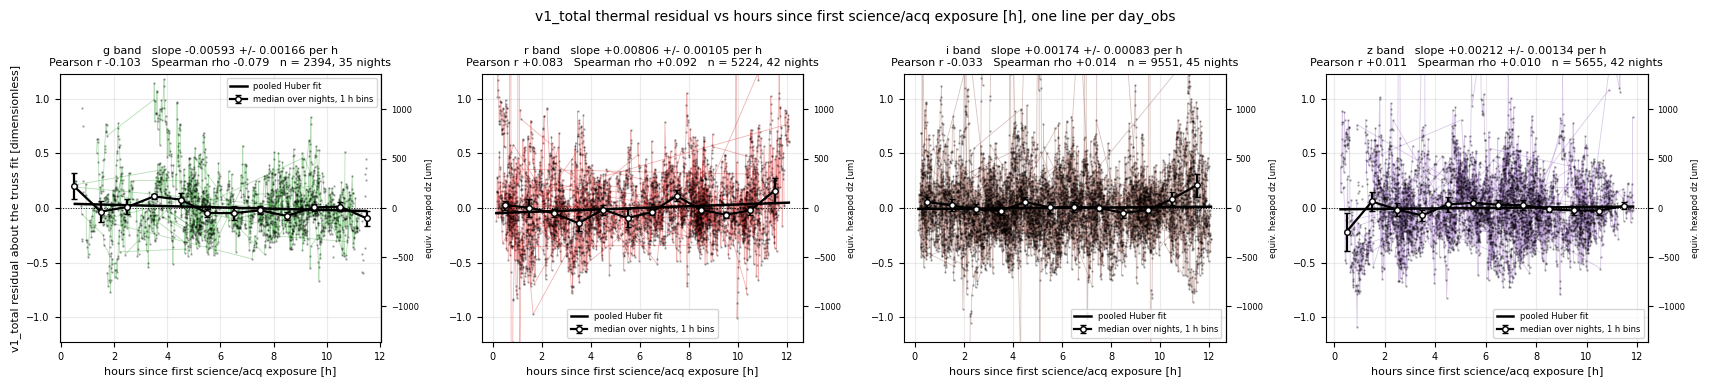

(b) aligned on the first science/acq exposure:
band    n  n_nights  slope_per_hour  slope_err  pearson_r  spearman_rho  median_night_slope  nmad_night_slope
   g 2394        35        -0.00593    0.00166   -0.10307      -0.07911             0.01310           0.08364
   r 5224        42         0.00806    0.00105    0.08310       0.09244             0.00023           0.04161
   i 9551        45         0.00174    0.00083   -0.03349       0.01383             0.00517           0.04615
   z 5655        42         0.00212    0.00134    0.01078       0.01029             0.01220           0.07899

                 alignment  band     pooled slope [1/h]  slope/err   median night slope   nMAD night
                  twilight     g      -0.00680 +/- 0.00171       -4.0             +0.01310      0.08364
                  twilight     r      +0.00786 +/- 0.00106       +7.4             +0.00023      0.04161
                  twilight     i      +0.00054 +/- 0.00083       +0.7             +0.00517   

In [41]:
trend_first = time_history_page(
    'hours_since_firstimg',
    f'hours since first {FIRST_IMG_TYPES[0]}/{FIRST_IMG_TYPES[1]} exposure [h]',
    'corner_z4_v1_resid_vs_hours_since_firstimg.png')
print(f'(b) aligned on the first {"/".join(FIRST_IMG_TYPES)} exposure:')
print(trend_first.round(5).to_string(index=False))

# Is either alignment showing a consistent drift? Two things have to hold: the pooled slope
# must be significant, and the per-night slopes must agree with each other rather than
# scattering around zero.
print(f'\n{"alignment":>26s} {"band":>5s} {"pooled slope [1/h]":>22s} '
      f'{"slope/err":>10s} {"median night slope":>20s} {"nMAD night":>12s}')
for _lab, _t in (('twilight', trend_twi), ('first image', trend_first)):
    for _, r in _t.iterrows():
        _sig = r.slope_per_hour / r.slope_err if r.slope_err else np.nan
        print(f'{_lab:>26s} {r.band:>5s} {r.slope_per_hour:+13.5f} '
              f'+/- {r.slope_err:.5f} {_sig:+10.1f} {r.median_night_slope:+20.5f} '
              f'{r.nmad_night_slope:12.5f}')
print('\nslope/err is dimensionless (Huber slope over its standard error). A consistent '
      'within-night\ndrift needs |slope/err| well above ~3 AND a median per-night slope of '
      'the same sign and size\nas the pooled one -- if the per-night nMAD swamps the median, '
      'the nights disagree and the\npooled slope is being set by a handful of them.')


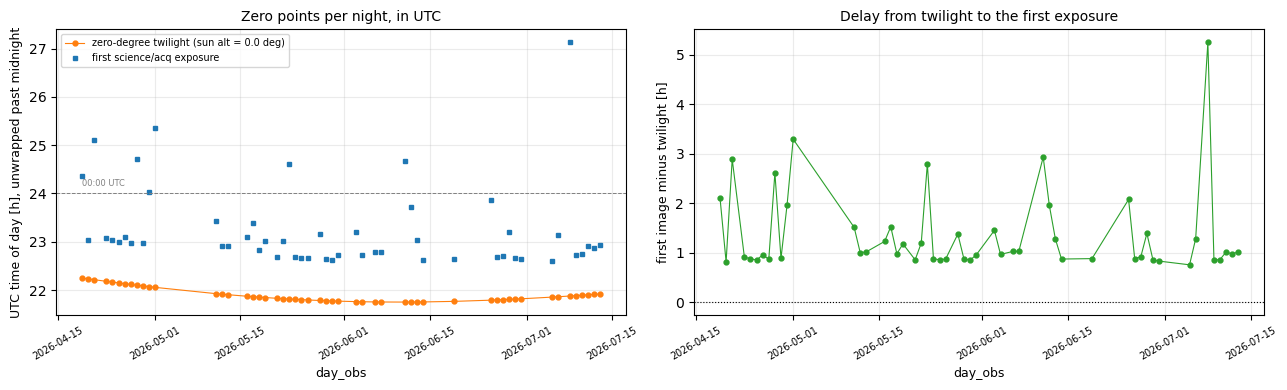

twilight UTC hour: 21.75 to 22.25 h over 52 nights (a 0.50 h seasonal swing)
nights whose first exposure fell after 00:00 UTC (unwrapped in the left panel): 8 of 52
nights where the first exposure PRECEDES zero-degree twilight: 0 of 52

per-night zero points (first 10 of 52):
 day_obs  twilight_utc_h  firstimg_utc_h  delay_h
20260419          22.249           0.357    2.108
20260420          22.231          23.045    0.814
20260421          22.214           1.104    2.890
20260423          22.181          23.088    0.908
20260424          22.164          23.044    0.880
20260425          22.148          22.996    0.848
20260426          22.132          23.089    0.957
20260427          22.116          22.981    0.866
20260428          22.100           0.713    2.613
20260429          22.085          22.970    0.885


In [42]:
# Validation of the two zero points: their UTC clock time per night. Twilight must trace a
# smooth seasonal curve (it is pure sun geometry); the first-image time is operational and so
# is allowed to scatter, but must sit AFTER twilight.
zp = (df.groupby('day_obs')
      .agg(mjd0_twilight=('mjd0_twilight', 'first'),
           mjd0_firstimg=('mjd0_firstimg', 'first'))
      .reset_index())
zp['date'] = pd.to_datetime(zp.day_obs.astype(str), format='%Y%m%d')


def _utc_hour(mjd):
    """UTC hour-of-day (0-24) for an MJD array, NaN-safe."""
    m = np.asarray(mjd, float)
    out = np.full(m.shape, np.nan)
    ok = np.isfinite(m)
    if ok.any():
        out[ok] = (m[ok] % 1.0) * 24.0
    return out


zp['twilight_utc_h'] = _utc_hour(zp.mjd0_twilight)
zp['firstimg_utc_h'] = _utc_hour(zp.mjd0_firstimg)
zp['delay_h'] = (zp.mjd0_firstimg - zp.mjd0_twilight) * 24.0

# Unwrap past midnight for PLOTTING only: a first exposure at 00:30 UTC is 2.5 h after a
# 22:00 UTC twilight, but its raw UTC hour of 0.5 would draw below it. Adding 24 h to any
# first-image hour that fell before its own twilight keeps the panel monotonic in real time.
# `firstimg_utc_h` itself is left as the true clock time.
zp['firstimg_utc_h_plot'] = np.where(zp.firstimg_utc_h < zp.twilight_utc_h,
                                     zp.firstimg_utc_h + 24.0, zp.firstimg_utc_h)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.0))
ax = axes[0]
ax.plot(zp.date, zp.twilight_utc_h, 'o-', ms=3.5, lw=0.8, color='tab:orange',
        label=f'zero-degree twilight (sun alt = {TWILIGHT_SUN_ALT_DEG:.1f} deg)')
ax.plot(zp.date, zp.firstimg_utc_h_plot, 's', ms=3.5, color='tab:blue',
        label=f'first {FIRST_IMG_TYPES[0]}/{FIRST_IMG_TYPES[1]} exposure')
ax.axhline(24.0, color='gray', lw=0.7, ls='--')
ax.text(zp.date.iloc[0], 24.15, '00:00 UTC', fontsize=6, color='gray')
ax.set_ylabel('UTC time of day [h], unwrapped past midnight', fontsize=9)
ax.set_xlabel('day_obs', fontsize=9)
ax.set_title('Zero points per night, in UTC', fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.25)
ax.tick_params(labelsize=7, axis='x', rotation=30)

ax = axes[1]
ax.plot(zp.date, zp.delay_h, 'o-', ms=3.5, lw=0.8, color='tab:green')
ax.axhline(0.0, color='k', lw=0.8, ls=':')
ax.set_ylabel('first image minus twilight [h]', fontsize=9)
ax.set_xlabel('day_obs', fontsize=9)
ax.set_title('Delay from twilight to the first exposure', fontsize=10)
ax.grid(alpha=0.25)
ax.tick_params(labelsize=7, axis='x', rotation=30)
fig.tight_layout()
fig.savefig(OUT / 'corner_z4_zero_points_validation.png', dpi=110)
plt.show()

print(f'twilight UTC hour: {zp.twilight_utc_h.min():.2f} to '
      f'{zp.twilight_utc_h.max():.2f} h over {len(zp)} nights '
      f'(a {zp.twilight_utc_h.max() - zp.twilight_utc_h.min():.2f} h seasonal swing)')
_wrap = int((zp.firstimg_utc_h < zp.twilight_utc_h).sum())
print(f'nights whose first exposure fell after 00:00 UTC (unwrapped in the left panel): '
      f'{_wrap} of {len(zp)}')
_neg = int((zp.delay_h < 0).sum())
print(f'nights where the first exposure PRECEDES zero-degree twilight: {_neg} of {len(zp)}'
      + ('  <-- expected: engineering/twilight-flat frames can start before sunset'
         if _neg else ''))
print(f'\nper-night zero points (first 10 of {len(zp)}):')
print(zp[['day_obs', 'twilight_utc_h', 'firstimg_utc_h', 'delay_h']]
      .head(10).round(3).to_string(index=False))


<a id="summary"></a>
## 13. Per-visit summary table

One row per science visit, holding the pointing, the three v-mode-1 components and their total,
**two** truss-fit predictions and their residuals, the full thermal channel set, air pressure,
the delivered image quality, and both time-since-zero-point measures. Written to parquet for
follow-up work outside this notebook.

Some columns need their definition stated because the name alone is ambiguous:

- **`v1_total`** is `v1_lut + v1_trim + MEASURED_SIGN * v1_meas` with `MEASURED_SIGN = -1`, so
  it is LUT + Trim **minus** the measured term. The sign is fixed in Section 8 from the
  BLOCK-T539 initial-alignment sequence, not fitted here. `v1_meas` itself is stored with its
  own sign as measured, *before* `MEASURED_SIGN` is applied, so any consumer can recombine the
  three components differently.
- **`v1_truss_fit`** is the per-band Huber fit of `v1_total` against `truss` evaluated at that
  visit's truss temperature — the prediction, not the residual. `v1_resid_truss` is
  `v1_total − v1_truss_fit`, the quantity Sections 10 to 12 analyse.
- **`v1_truss_fit_lutptrim`** and **`v1_resid_truss_lutptrim`** are the same pair for the
  **commanded state alone**, `v1_lut_trim = v1_lut + v1_trim`, with no measured term. The
  measured term is a four-field-point estimate of a field-constant quantity and is the noisiest
  of the three components, so this residual shows the within-night focus excursions with less
  measurement noise on top of them. `v1_lut_trim` itself is stored, so the pair is
  self-contained.
- **`pressure_pa`** is in **pascals**, as the ConsDB stores it — median about 74300 Pa at the
  2663 m elevation of Cerro Pachón, not the ~1013 hPa of sea level.
- **`psf_fwhm`** is derived here, not a ConsDB column: `psf_sigma_median` is a Gaussian sigma in
  **pixels**, converted with the Gaussian factor 2.3548 (dimensionless) and the 0.2 arcsec/pixel
  plate scale. The raw `psf_sigma_median` is kept alongside it.

The camera **rotator** column is `physical_rotator_angle` from `cdb_lsstcam.visit1_quicklook`.
`sky_rotation` is carried alongside it but is the sky position angle, a different quantity.

`donut_blur_fwhm`, `aos_fwhm` and `psf_sigma_median` arrive from the ConsDB as `object` dtype
and are cast to numeric in Section 3; a consumer reading the parquet gets float columns.


In [38]:
SUMMARY_COLS = {
    # name in the output      : (source column, unit / meaning)
    'day_obs':                 ('day_obs', 'observing night, YYYYMMDD'),
    'seq_num':                 ('seq_num', 'sequence number within the night'),
    'visit_id':                ('visit_id', 'ConsDB visit identifier'),
    'band':                    ('band', 'filter band, g/r/i/z'),
    'exp_midpt_mjd':           ('exp_midpt_mjd', 'MJD (UTC) of exposure midpoint'),
    'elevation_deg':           ('altitude', 'telescope elevation, deg'),
    'azimuth_deg':             ('azimuth', 'telescope azimuth, deg'),
    'rotator_deg':             ('physical_rotator_angle', 'camera physical rotator angle, deg'),
    'sky_rotation_deg':        ('sky_rotation', 'sky position angle, deg (NOT the rotator)'),
    'v1_lut':                  ('v1_lut', 'v-mode 1 of the hexapod LUT, dimensionless'),
    'v1_trim':                 ('v1_trim', 'v-mode 1 of the Trim, dimensionless'),
    'v1_meas':                 ('v1_meas', 'v-mode 1 equivalent of the four-corner mean Z4, '
                                           'dimensionless, sign as measured'),
    'v1_total':                ('v1_total', 'v1_lut + v1_trim + MEASURED_SIGN * v1_meas, '
                                            'dimensionless'),
    'v1_lut_trim':             ('v1_lut_trim', 'v1_lut + v1_trim, the COMMANDED state with no '
                                               'measured term, dimensionless'),
    'v1_truss_fit':            (None, 'per-band Huber fit of v1_total vs truss, evaluated '
                                      'at this visit, dimensionless'),
    'v1_resid_truss':          ('v1_resid_truss', 'v1_total - v1_truss_fit, dimensionless'),
    # The same pair for the commanded state alone. The measured term is the noisiest of the
    # three components, so this residual is the cleaner view of the within-night focus
    # excursions -- which is what it exists for.
    'v1_truss_fit_lutptrim':   (None, 'per-band Huber fit of v1_lut_trim vs truss, evaluated '
                                      'at this visit, dimensionless'),
    'v1_resid_truss_lutptrim': ('v1_resid_truss_lutptrim',
                                'v1_lut_trim - v1_truss_fit_lutptrim, dimensionless'),
    'truss_temp':              ('truss', 'mean of the two TMA truss thermocouples, deg C'),
    'cam_body_temp':           ('camera', 'camera body AverageTemp from lsst.MTCamera, deg C'),
    'outside_temp':            ('ambient', 'outside air temperature, deg C'),
    'delta_mjd_twilight':      (None, 'exp_midpt_mjd - MJD of zero-degree evening twilight, d'),
    'delta_mjd_firstimg':      (None, 'exp_midpt_mjd - MJD of first science/acq exposure, d'),
    # Air pressure and delivered image quality, straight from the ConsDB visit tables.
    'pressure_pa':             (PRESSURE_COL, 'ambient air pressure, Pa (NOT hPa)'),
    'donut_blur_fwhm':         ('donut_blur_fwhm', 'ConsDB donut-blur FWHM, arcsec'),
    'aos_fwhm':                ('aos_fwhm', 'ConsDB AOS FWHM contribution, arcsec'),
    'psf_sigma_median':        ('psf_sigma_median', 'ConsDB median PSF Gaussian sigma, pixels'),
    'psf_fwhm':                ('psf_fwhm', f'{SIGMA_TO_FWHM:.4f} * psf_sigma_median * '
                                            f'{PIXEL_SCALE_ARCSEC} arcsec/pixel, arcsec'),
}

# The remaining thermal channels, carried so the thermal question can be revisited without
# refetching. CORE_THERMAL already holds the truss pair, the camera body and the outside air
# under their own names above; these are the rest of it, stored under their source names.
_THERMAL_EXTRA = [c for c in CORE_THERMAL
                  if c not in (TRUSS_COLS + [AMBIENT_COL, CAM_COL])]
_THERMAL_UNITS = {'cam_air_temp': 'air temperature near the camera (salindex 111), deg C',
                  'm2_air_temp': 'air temperature near M2 (salindex 112), deg C',
                  'm1m3_air_temp': 'air temperature near M1M3 (salindex 113), deg C',
                  'm2_delta_t': 'm2_air_temp - m1m3_air_temp, deg C',
                  'cam_m1m3_delta_t': 'cam_air_temp - m1m3_air_temp, deg C',
                  'dome_delta_t': 'outside_temp - m1m3_air_temp, deg C'}
for _c in _THERMAL_EXTRA:
    SUMMARY_COLS[_c] = (_c, _THERMAL_UNITS.get(_c, 'thermal channel, deg C'))
# The two truss thermocouples individually, alongside their mean in truss_temp.
for _c in TRUSS_COLS:
    SUMMARY_COLS[_c] = (_c, f'{_c} TMA truss thermocouple, deg C')

summary = pd.DataFrame(index=df.index)
for _out, (_src, _desc) in SUMMARY_COLS.items():
    if _src is not None:
        summary[_out] = df[_src].to_numpy() if _src in df else np.nan

# The truss-fit PREDICTION, rebuilt from the same per-band fits Section 10 subtracted, so that
# v1_truss_fit + v1_resid_truss == v1_total exactly rather than approximately.
def _truss_prediction(fits):
    """Evaluate a per-band Huber truss fit at every visit's own truss temperature.

    Parameters
    ----------
    fits : `dict`
        Band -> `huber_fit` result dict, as returned by `truss_residual_per_band`.

    Returns
    -------
    pred : `numpy.ndarray`
        Predicted v-mode-1 amplitude per row of `df`, dimensionless, NaN for bands with no
        fit or rows with a non-finite truss temperature.
    """
    pred = np.full(len(df), np.nan)
    x = df.truss.to_numpy(float)
    for b, r in fits.items():
        m = (df.band == b).to_numpy()
        pred[m] = r['intercept'] + r['slope'] * x[m]
    return pred

summary['v1_truss_fit'] = _truss_prediction(TRUSS_FITS)
summary['v1_truss_fit_lutptrim'] = _truss_prediction(TRUSS_FITS_LUTPTRIM)

# Deltas in DAYS, as MJD differences -- the hours_since_* columns used for plotting are these
# times 24.
summary['delta_mjd_twilight'] = (df.exp_midpt_mjd - df.mjd0_twilight).to_numpy(float)
summary['delta_mjd_firstimg'] = (df.exp_midpt_mjd - df.mjd0_firstimg).to_numpy(float)

summary = summary[list(SUMMARY_COLS)]
for _c in ('day_obs', 'seq_num', 'visit_id'):
    summary[_c] = summary[_c].astype('int64')

# Closure check on BOTH fit/residual pairs: the fit plus the residual must reproduce the
# fitted quantity wherever all three are finite. A mismatch would mean the stored fits no
# longer match the stored residuals.
for _fitc, _resc, _totc in (('v1_truss_fit', 'v1_resid_truss', 'v1_total'),
                            ('v1_truss_fit_lutptrim', 'v1_resid_truss_lutptrim',
                             'v1_lut_trim')):
    _ok = np.isfinite(summary[[_totc, _fitc, _resc]].to_numpy(float)).all(axis=1)
    _clo = (summary[_fitc] + summary[_resc] - summary[_totc]).to_numpy(float)[_ok]
    print(f'closure {_fitc} + {_resc} - {_totc}: max |error| = {np.abs(_clo).max():.3e} '
          f'(dimensionless, over n = {int(_ok.sum())} rows with all three finite)')

SUMMARY_PARQUET = OUT / (f'corner_z4_v1_summary_{DAY_OBS_MIN}_{DAY_OBS_MAX}'
                         f'_{CACHE_VERSION}.parquet')
summary.to_parquet(SUMMARY_PARQUET, index=False)
print(f'\nwrote n = {len(summary)} rows x {len(summary.columns)} columns to\n  {SUMMARY_PARQUET}')

# Coverage per column. `band` is a string, so count non-null rather than finite -- running
# to_numeric over it would report 0 populated for a column that is in fact complete.
print(f'\n{"column":24s} {"n present":>9s} {"fraction":>9s}  units / meaning')
for _out, (_src, _desc) in SUMMARY_COLS.items():
    _col = summary[_out]
    if pd.api.types.is_numeric_dtype(_col):
        _n = int(np.isfinite(_col.to_numpy(float)).sum())
    else:
        _n = int(_col.notna().sum())
    print(f'{_out:24s} {_n:9d} {_n / len(summary):9.4f}  {_desc}')

# Read back what was written: a parquet that cannot round-trip its dtypes is not useful to
# the follow-up work this table exists for.
_rt = pd.read_parquet(SUMMARY_PARQUET)
assert len(_rt) == len(summary) and list(_rt.columns) == list(summary.columns)
_num = [c for c in summary.columns if pd.api.types.is_numeric_dtype(summary[c])]
_maxdiff = float(np.nanmax(np.abs(_rt[_num].to_numpy(float) - summary[_num].to_numpy(float))))
print(f'read-back check: {len(_rt)} rows, {len(_rt.columns)} columns, '
      f'max |difference| over the {len(_num)} numeric columns = {_maxdiff:.3e}')

print('\nfirst 8 rows:')
_show = ['day_obs', 'seq_num', 'band', 'elevation_deg', 'rotator_deg',
         'v1_lut', 'v1_trim', 'v1_meas', 'v1_total', 'v1_lut_trim',
         'v1_resid_truss', 'v1_resid_truss_lutptrim', 'truss_temp', 'cam_body_temp',
         'pressure_pa', 'psf_fwhm', 'aos_fwhm', 'delta_mjd_twilight']
print(summary[_show].head(8).to_string(index=False))


closure v1_truss_fit + v1_resid_truss - v1_total: max |error| = 4.441e-16 (dimensionless, over n = 22824 rows with all three finite)

wrote n = 27671 rows x 20 columns to
  /home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_v1_summary_20260419_20260713_v2.parquet

column                   n present  fraction  units / meaning
day_obs                      27671    1.0000  observing night, YYYYMMDD
seq_num                      27671    1.0000  sequence number within the night
visit_id                     27671    1.0000  ConsDB visit identifier
band                         27671    1.0000  filter band, g/r/i/z
exp_midpt_mjd                27671    1.0000  MJD (UTC) of exposure midpoint
elevation_deg                27671    1.0000  telescope elevation, deg
azimuth_deg                  27671    1.0000  telescope azimuth, deg
rotator_deg                  25439    0.9193  camera physical rotator angle, deg
sky_rotation_deg             27671    1.0000  sky positio

<a id="Interactive work"></a>
## 14. Interactive work

In [43]:
df = pd.read_parquet('/home/r/roodman/notebooks/rubin-work/aos/output/notebooks/correlations/corner_z4_v1_summary_20260419_20260713_v2.parquet')

In [45]:
df.columns

Index(['day_obs', 'seq_num', 'visit_id', 'band', 'exp_midpt_mjd',
       'elevation_deg', 'azimuth_deg', 'rotator_deg', 'sky_rotation_deg',
       'v1_lut', 'v1_trim', 'v1_meas', 'v1_total', 'v1_truss_fit',
       'v1_resid_truss', 'truss_temp', 'cam_body_temp', 'outside_temp',
       'delta_mjd_twilight', 'delta_mjd_firstimg'],
      dtype='object')

Text(0, 0.5, 'v1 total - v1 from Truss temp')

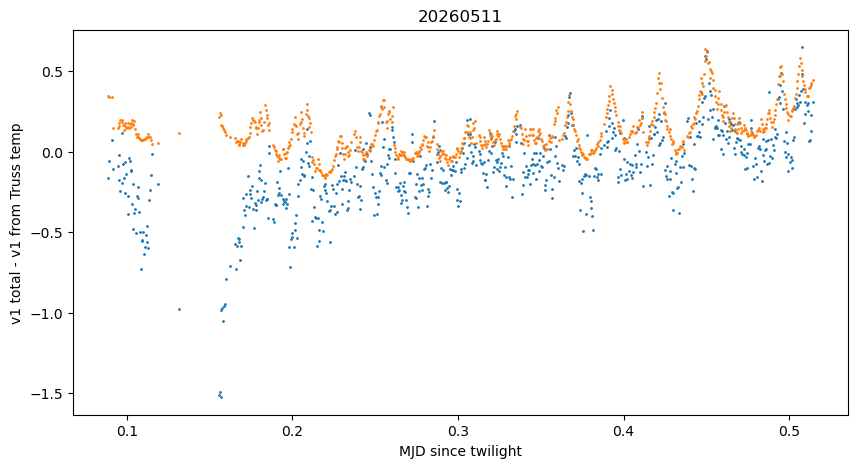

In [64]:
f,ax = plt.subplots(1,1,figsize=(10,5))
day_obs = 20260511
dfonly = df[(df['day_obs']==day_obs)]
_ = ax.scatter(dfonly['delta_mjd_twilight'],dfonly['v1_resid_truss'],s=1.)
_ = ax.scatter(dfonly['delta_mjd_twilight'],dfonly['v1_lut']+dfonly['v1_trim']-dfonly['v1_truss_fit'],s=1.)

ax.set_title(day_obs)
ax.set_xlabel('MJD since twilight')
ax.set_ylabel('v1 total - v1 from Truss temp')

Text(0, 0.5, 'v1 total - v1 from Truss temp')

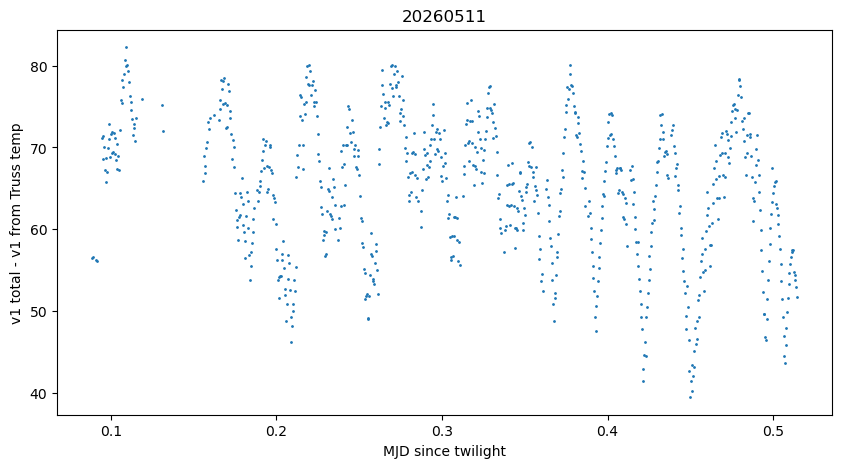

In [65]:
f,ax = plt.subplots(1,1,figsize=(10,5))
day_obs = 20260511
dfonly = df[(df['day_obs']==day_obs)]
_ = ax.scatter(dfonly['delta_mjd_twilight'],dfonly['elevation_deg'],s=1.)

ax.set_title(day_obs)
ax.set_xlabel('MJD since twilight')
ax.set_ylabel('v1 total - v1 from Truss temp')

(-1.0, 1.0)

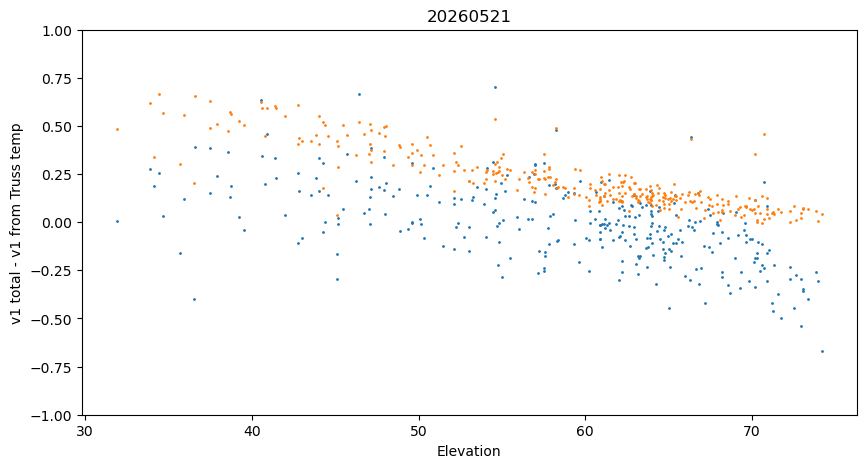

In [87]:
f,ax = plt.subplots(1,1,figsize=(10,5))
day_obs = 20260521
dfonly = df[(df['day_obs']==day_obs)]
_ = ax.scatter(dfonly['elevation_deg'],dfonly['v1_resid_truss'],s=1.)
_ = ax.scatter(dfonly['elevation_deg'],dfonly['v1_lut']+dfonly['v1_trim']-dfonly['v1_truss_fit'],s=1.)

ax.set_title(day_obs)
ax.set_xlabel('Elevation')
ax.set_ylabel('v1 total - v1 from Truss temp')
ax.set_ylim(-1.0,1.0)

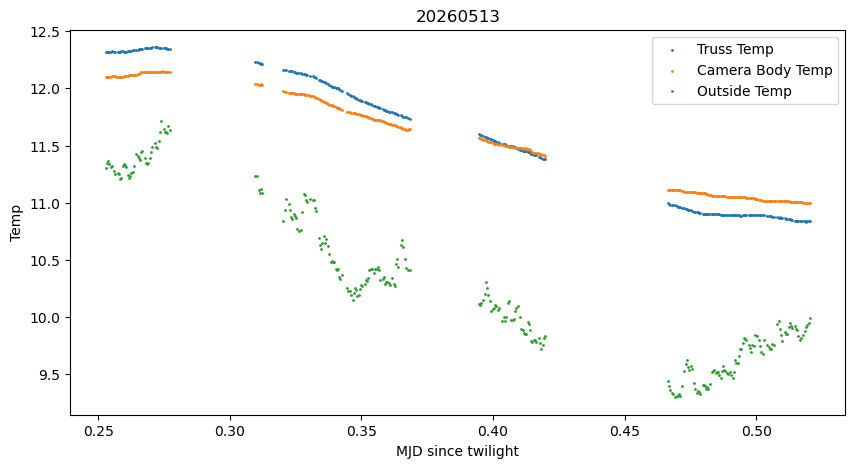

In [59]:
f,ax = plt.subplots(1,1,figsize=(10,5))
day_obs = 20260513
dfonly = df[(df['day_obs']==day_obs)]
_ = ax.scatter(dfonly['delta_mjd_twilight'],dfonly['truss_temp'],s=1.,label='Truss Temp')
_ = ax.scatter(dfonly['delta_mjd_twilight'],dfonly['cam_body_temp'],s=1.,label='Camera Body Temp')
_ = ax.scatter(dfonly['delta_mjd_twilight'],dfonly['outside_temp'],s=1.,label='Outside Temp')

ax.set_title(day_obs)
ax.set_xlabel('MJD since twilight')
ax.set_ylabel('Temp')
ax.legend()

<a id="findings"></a>
## 14. Findings

Measured on n = 27671 science visits in g/r/i/z over `day_obs` 20260419 to 20260713 (52
nights), of which 25430 carry a finite `v1_total`.

### The commanded state tracks truss temperature; the measured wavefront does not

| v-mode 1 form | Huber slope [dimensionless per °C] | Pearson r | Spearman rho | n | residual nMAD [dimensionless] |
|---|---|---|---|---|---|
| LUT + Trim | +0.10524 ± 0.00163 | +0.341 | +0.396 | 24831 | 0.5171 |
| LUT + Trim + measured | +0.09242 ± 0.00186 | +0.289 | +0.321 | 22824 | 0.5660 |
| measured Z4 alone | −0.00150 ± 0.00050 | −0.007 | −0.008 | 22824 | 0.1540 |

The measured term's slope is 70× smaller than the commanded one, with a correlation
indistinguishable from zero. Truss temperature therefore accounts for almost none of the
*measured* uniform defocus on science exposures — the science-image counterpart of the Full
Array Mode (FAM) result, reached from corner-sensor optical path difference (OPD) rather than
a 189-detector Double Zernike fit.

### The camera body temperature is a distinct, better-covered channel

The camera **body** temperature comes from `lsst.MTCamera.utiltrunk_body` `AverageTemp` — the
camera's own InfluxDB database, not the Environmental Sensor Suite (ESS). It resolves for
27027 of 27671 visits (97.67% dimensionless, finite readings over science visits), against
89.74% for every ESS air channel, with a median of 24 samples averaged inside the ±120 s
window. Median 9.987 °C, range +4.457 to +13.644 °C.

It is not the same quantity as the air near the camera, though the two are tightly coupled:
body minus air near camera has a median of −0.488 °C with an nMAD of 0.606 °C and Pearson
r = +0.9791 (n = 24251) between them. The body runs about half a degree cooler than the
surrounding air, and tracks it closely. Against `v1_total` it
gives Huber slope +0.09993 ± 0.00192 per °C, Pearson r = +0.285, n = 24786 — statistically
indistinguishable from the truss's +0.09242 ± 0.00186 per °C, as expected for a temperature
that follows the same nightly cooling.

### Residuals about the per-band truss relation are wide and near-Gaussian

Subtracting each band's own Huber fit of `v1_total` against mean truss temperature:

| band | Huber slope [dimensionless per °C] | residual nMAD [dimensionless] | residual nMAD [µm equivalent hexapod dz] | n |
|---|---|---|---|---|
| g | +0.11529 ± 0.00218 | 0.2152 | 238.8 | 2394 |
| r | +0.11564 ± 0.00170 | 0.2432 | 270.0 | 5224 |
| i | +0.09135 ± 0.00125 | 0.2414 | 267.9 | 9551 |
| z | +0.10171 ± 0.00164 | 0.2670 | 296.3 | 5655 |

Pooled after per-band subtraction: median −0.00780, nMAD 0.2450 (dimensionless), equal to
271.9 µm of equivalent hexapod dz. The residual is large — hundreds of µm of hexapod motion —
so truss temperature is far from a complete description of the commanded focus state. The
per-band slopes agree to about 20%, with the i band lowest.

**The residual is not symmetric.** The core is close to a Gaussian of the same nMAD, but there
is a one-sided **positive** tail in every band:

| band | n | beyond +3 nMAD [% of visits] | beyond −3 nMAD [% of visits] | ratio positive/negative [dimensionless] |
|---|---|---|---|---|
| g | 2394 | 2.38 | 0.25 | 9.5 |
| r | 5224 | 2.01 | 0.38 | 5.2 |
| i | 9551 | 3.04 | 0.34 | 9.1 |
| z | 5655 | 0.88 | 0.04 | 25.0 |

A Gaussian would put 0.135% on each side. The positive side is 7 to 23× that, the negative side
is at or below it, and the asymmetry runs the same way in all four bands — so this is not
measurement noise on the wavefront term, which would be symmetric. It is a population of visits
whose commanded focus state sat well *above* the truss relation, and it is the reason the fits
here are robust rather than ordinary least squares: an unweighted fit would be pulled by that
tail.

### No other thermal channel adds information beyond the truss

Ten `CORE_THERMAL` channels, scored out of sample with `GroupKFold` on `day_obs` (grouping is
required: thermal state is correlated within a night, and an ungrouped split leaks it):

| band | n | nights | R² truss only | R² ridge, all 10 | R² gradient boosting, all 10 |
|---|---|---|---|---|---|
| g | 2202 | 34 | +0.3898 | +0.4759 | +0.2501 |
| r | 4992 | 41 | +0.3545 | +0.3932 | +0.2964 |
| i | 9397 | 44 | +0.1603 | +0.1381 | −0.0181 |
| z | 5653 | 41 | +0.3255 | +0.3952 | +0.2236 |

**The answer is no, on two independent grounds.** The mean ridge gain is +0.0431 in R²
(dimensionless), which is *smaller* than the 0.0880 across-band standard deviation of the
baseline R² itself — the improvement does not exceed the spread of the thing it is measured
against. And it is not uniform: the i band, the largest sample at n = 9397, gets *worse*
(−0.0222). Gradient boosting is worse than the truss-only baseline in **every** band
(−0.0582 to −0.1784), i.e. no exploitable nonlinearity; converted to a residual scatter ratio
it inflates the nMAD by 4.4% to 10.9% (dimensionless, GB over truss-only).

Permutation importance puts `cam_AverageTemp` (mean drop in R² 0.3596) and
`tma_truss_temp_pxpy` (0.3498) far above everything else, with the remaining eight channels
under 0.08 and several negative. The camera body and one truss thermocouple carry the signal;
the rest is redundant, which is what was expected going in.

### The residual shows no consistent within-night drift

Against hours since **zero-degree evening twilight** (a) and hours since the **first science
or acquisition exposure** (b):

| alignment | band | pooled Huber slope [dimensionless per h] | slope/err | median per-night slope | nMAD of per-night slopes |
|---|---|---|---|---|---|
| twilight | g | −0.00680 ± 0.00171 | −4.0 | +0.01310 | 0.08364 |
| twilight | r | +0.00786 ± 0.00106 | +7.4 | +0.00023 | 0.04161 |
| twilight | i | +0.00054 ± 0.00083 | +0.7 | +0.00517 | 0.04615 |
| twilight | z | +0.00044 ± 0.00133 | +0.3 | +0.01220 | 0.07899 |
| first image | g | −0.00593 ± 0.00166 | −3.6 | +0.01310 | 0.08364 |
| first image | r | +0.00806 ± 0.00105 | +7.7 | +0.00023 | 0.04161 |
| first image | i | +0.00174 ± 0.00083 | +2.1 | +0.00517 | 0.04615 |
| first image | z | +0.00212 ± 0.00134 | +1.6 | +0.01220 | 0.07899 |

**The direct test is the binned median.** In one-hour bins, the median residual across nights
sits flat on zero to within about ±0.05 (dimensionless, equal to ±55 µm of equivalent hexapod
dz) from the start of the night to the end, in every band and under both alignments, with error
bars (nMAD/sqrt(n_nights)) of the same size as the excursions. The only structure is a small
positive g-band offset in the first hour and a mild upturn in the final bin of r/i/z, where the
night count is lowest. There is no ramp.

Three further things rule out a consistent drift:

1. **The sign is not consistent across bands.** g is negative and r is positive, both at
   |slope/err| above 3, under *both* alignments. A real thermal-lag drift would not reverse
   sign between two adjacent filters.
2. **The nights disagree with each other.** The nMAD of the per-night slopes (0.042 to 0.084
   dimensionless per h) is 3 to 180× the median per-night slope, so the pooled slope is being
   set by the spread between nights rather than by a shape they share.
3. **The size is negligible.** Even the largest pooled slope, +0.008 per h, integrated over a
   9-hour night gives 0.07 dimensionless — under 30% of the 0.245 residual nMAD it would have
   to explain.

Neither zero point does better than the other, and their near-identical results are themselves
informative: since the two differ by the observing-start delay (median +0.99 h, range +0.75 to
+5.26 h over 52 nights), a drift keyed to either sunset or the start of operations would have
shown up in one and been smeared in the other.

**Validation of the zero points.** Twilight moves smoothly from 22.25 h to 21.75 h UTC across
the range — a 0.50 h seasonal swing, as expected for pure sun geometry over April to July at
this latitude — and the first exposure follows twilight, never precedes it, on all 52 nights.
The delay from twilight to first image is short on most nights (median +0.99 h) with a tail to
+5.26 h on nights that started late. On 8 of the 52 nights the first exposure fell after 00:00
UTC, so the left validation panel plots the first-image hour unwrapped past midnight; without
that it would draw those nights below their own twilight.

### Method note

The `MEASURED_SIGN = -1` convention is fixed in Section 8 from the BLOCK-T539
`infocus_initial_alignment` sequence on 20260513, not from any fit here: with a +3.87 µm of
wavefront error the Active Optics System (AOS) commanded −119.7 µm of camera hexapod dz, so
the commanded motion opposes the measured Z4 and a surviving residual enters the sum with the
sign that cancels it. The same sequence confirms `Trim = Trim_previous + Tweak` exactly, the
n → n+2 correction latency, and a proportional gain of 0.75 (dimensionless) for this block
rather than the usual 0.3.


In [38]:
lines = []
n_tot = int(np.isfinite(df.v1_total).sum())
lines.append(f'Sample: n = {len(df)} science visits in g/r/i/z over day_obs {DAY_OBS_MIN} to '
             f'{DAY_OBS_MAX} ({df.day_obs.nunique()} nights), of which n = {n_tot} carry a '
             f'finite v1_total.')
for q in ('v1_total', 'v1_lut_trim', 'v1_meas'):
    r = pooled[(pooled.quantity == q) & (pooled.temperature == 'truss')]
    if len(r):
        r = r.iloc[0]
        lines.append(f'{q} against mean TMA truss temperature: Huber slope '
                     f'{r.slope:+.5f} +/- {r.slope_err:.5f} per deg C (dimensionless v-mode 1 '
                     f'amplitude per deg C), Pearson r = {r.pearson_r:+.3f}, Spearman rho = '
                     f'{r.spearman_rho:+.3f}, n = {int(r.n)}, residual nMAD '
                     f'{r.resid_nmad:.4f} (dimensionless).')
for t, nm in (('ambient', 'outside ambient temperature'), ('camera', CAMERA_LABEL)):
    r = pooled[(pooled.quantity == 'v1_total') & (pooled.temperature == t)]
    if len(r):
        r = r.iloc[0]
        lines.append(f'v1_total against {nm}: Huber slope {r.slope:+.5f} +/- '
                     f'{r.slope_err:.5f} per deg C, Pearson r = {r.pearson_r:+.3f}, '
                     f'Spearman rho = {r.spearman_rho:+.3f}, n = {int(r.n)}.')
lines.append(f'The measured wavefront term is small next to the commanded one: nMAD '
             f'{nmad((MEASURED_SIGN*df.v1_meas).to_numpy()):.4f} against '
             f'{nmad(df.v1_lut_trim.to_numpy()):.4f} for LUT+Trim (both dimensionless), so '
             f'v1_total is dominated by the commanded state.')
lines.append(f'The sign with which the measured term enters is MEASURED_SIGN = '
             f'{MEASURED_SIGN:+.0f}, determined in Section 8 from the {SIGN_BLOCK} '
             f'initial-alignment sequence on {SIGN_DAY_OBS} rather than from any fit here. On '
             f'the two visits with a large focus error the AOS commanded a hexapod dz opposite '
             f'in sign to the measured Z4 ({big.iloc[0].z4_mean:+.2f} um of wavefront -> '
             f'{big.iloc[0].tweak_cam_dz:+.1f} um camera dz; {big.iloc[1].z4_mean:+.2f} -> '
             f'{big.iloc[1].tweak_cam_dz:+.1f}), so a surviving residual Z4 must be added to '
             f'the commanded state with the sign that cancels it. That sequence also confirms '
             f'Trim = Trim_prev + Tweak exactly, and that the AOS emitted a correction only on '
             f'seq_num {[int(x) for x in t539.seq_num]} -- every second image, as the block '
             f'applies image n\'s correction at n+2. Its proportional gain is '
             f'{float(np.median(kp)):.2f} (dimensionless), not the usual 0.3, with zero '
             f'integral and derivative gain.')
print('\n\n'.join(lines))

Sample: n = 27671 science visits in g/r/i/z over day_obs 20260419 to 20260713 (52 nights), of which n = 25430 carry a finite v1_total.

v1_total against mean TMA truss temperature: Huber slope +0.09242 +/- 0.00186 per deg C (dimensionless v-mode 1 amplitude per deg C), Pearson r = +0.289, Spearman rho = +0.321, n = 22824, residual nMAD 0.5660 (dimensionless).

v1_lut_trim against mean TMA truss temperature: Huber slope +0.10524 +/- 0.00163 per deg C (dimensionless v-mode 1 amplitude per deg C), Pearson r = +0.341, Spearman rho = +0.396, n = 24831, residual nMAD 0.5171 (dimensionless).

v1_meas against mean TMA truss temperature: Huber slope -0.00150 +/- 0.00050 per deg C (dimensionless v-mode 1 amplitude per deg C), Pearson r = -0.007, Spearman rho = -0.008, n = 22824, residual nMAD 0.1540 (dimensionless).

v1_total against outside ambient temperature: Huber slope +0.07083 +/- 0.00174 per deg C, Pearson r = +0.248, Spearman rho = +0.289, n = 22824.

v1_total against camera body tempera

Traceback (most recent call last):
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.1.0-exact/lib/python3.13/site-packages/ipykernel/__main__.py", line 5, in <module>
    app.launch_new_instance()
    ~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.1.0-exact/lib/python3.13/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
    ~~~~~~~~~^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.1.0-exact/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
    ~~~~~~~~~~~~~~~~~~^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.1.0-exact/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/lsst/software/stack/conda/envs/lsst-